# **Project Name**    -  **Flipkart Customer Service Satisfaction Prediction**


##### **Project Type**    - Classification
##### **Contribution**    - Individual


# **Project Summary**

##
Customer satisfaction is a critical measure of service quality and plays a significant role in customer retention, business growth, and brand reputation. Organizations regularly collect Customer Satisfaction (CSAT) scores to evaluate the effectiveness of their customer support services and identify areas requiring improvement. However, customer feedback is typically received only after service interactions have been completed, making it difficult to address dissatisfaction proactively. This project aims to overcome this limitation by developing a machine learning model capable of predicting Customer Satisfaction (CSAT) scores based on customer support interaction data. By accurately forecasting customer satisfaction, organizations can identify potentially dissatisfied customers early, improve support quality, and make informed operational decisions.

The project follows a comprehensive end-to-end machine learning workflow, beginning with data collection, preprocessing, exploratory data analysis (EDA), feature engineering, statistical hypothesis testing, model development, optimization, evaluation, and model explainability. The dataset consists of approximately **86,000 customer support interactions** containing both numerical and categorical variables. Key features include support channel, issue category, product category, customer remarks, item price, response time, handling time, agent details, supervisor, manager, tenure bucket, and agent shift. The target variable is the **CSAT Score**, a multiclass classification problem with five satisfaction levels ranging from **1 (Very Dissatisfied)** to **5 (Highly Satisfied)**.

Data preprocessing was a crucial stage of the project. Missing values were handled using appropriate imputation techniques based on feature type, while duplicate records were identified and removed to improve data quality. Categorical variables were transformed using Label Encoding and One-Hot Encoding, and numerical features were standardized using StandardScaler to ensure consistent feature scales. Since the dataset exhibited a significant class imbalance, with most observations belonging to **CSAT Score 5**, the **Synthetic Minority Oversampling Technique (SMOTE)** was applied to the training dataset to generate synthetic samples for minority classes and improve model learning.

Extensive Exploratory Data Analysis (EDA) was conducted to understand customer behavior and identify meaningful business insights. Various univariate, bivariate, and multivariate visualizations were created to analyze customer satisfaction distribution, support channels, issue categories, tenure buckets, response time, and product categories. The analysis revealed that **Inbound** was the most frequently used support channel, while **Returns** and **Order Related** issues accounted for the majority of customer queries. Statistical hypothesis testing using **Chi-Square Tests** and **ANOVA** confirmed significant relationships between customer satisfaction and several operational factors, providing statistical support for the observed patterns.

Three supervised machine learning models were implemented and compared: **Logistic Regression**, **Random Forest Classifier**, and **XGBoost Classifier**. Model performance was evaluated using **Accuracy, Precision, Recall, F1-Score, Confusion Matrix,** and **Classification Report**. Among the evaluated models, **XGBoost** achieved the best performance, obtaining an accuracy of approximately **67.31%** after hyperparameter tuning with **GridSearchCV**. The final model was further validated using **5-Fold Cross Validation**, achieving an average validation accuracy of approximately **69.54%**, indicating strong stability and good generalization on unseen data.

To improve transparency and trustworthiness, **SHAP (SHapley Additive Explanations)** was used to interpret the predictions of the final XGBoost model. SHAP analysis identified **Response Time**, **Agent Shift**, **Order Related Category**, **Agent Name**, and **Tenure Bucket** as the most influential features affecting customer satisfaction predictions. These insights provide valuable guidance for organizations to optimize customer support operations, improve service quality, and enhance customer experience.

Overall, this project demonstrates the practical application of machine learning for customer service analytics by transforming historical support data into actionable business insights. The developed model enables organizations to predict customer satisfaction proactively, prioritize high-risk interactions, and support data-driven decision-making. The solution can be further enhanced by integrating Natural Language Processing (NLP) for customer remarks, deploying the model using Streamlit or Azure Machine Learning, and continuously retraining the model with new customer interaction data to improve long-term performance and adaptability.


# **GitHub Link**-

## https://github.com/abhisheksinha5/Customer-Satisfaction-CSAT-Prediction-Using-Machine-Learning

# **Problem Statement**


## **Problem Statement**

## **Business Problem Overview**

**Customer Satisfaction (CSAT)** is one of the most important **Key Performance Indicators (KPIs)** for any **e-commerce platform**, as it directly reflects the quality of customer support and overall customer experience. A **high CSAT Score** indicates that customers are satisfied with the support they receive, whereas a **low CSAT Score** highlights areas that require improvement in the customer service process.

As one of India's leading **e-commerce companies**, **Flipkart** handles a large number of customer interactions every day through multiple support channels such as **Inbound Calls, Outbound Calls, and Email**. Customers contact the support team regarding issues related to **orders, returns, cancellations, product queries, installations, refunds, and other service requests**. Providing timely and effective resolutions to these issues is essential for maintaining **customer trust**, **brand reputation**, and **customer loyalty**.

The objective of this project is to build a **Machine Learning Classification Model** that can **predict the Customer Satisfaction (CSAT) Score** using customer interaction details, order information, product details, support channel information, and agent-related attributes. By identifying the **key factors** that influence customer satisfaction, Flipkart can improve its **customer support operations**, enhance **agent performance**, reduce customer dissatisfaction, and make **data-driven business decisions** to deliver a better customer experience.

## **Project Objective**

The primary objective of this project is to develop a **Machine Learning Classification Model** that can accurately **predict the Customer Satisfaction (CSAT) Score** based on customer interaction details, order information, product details, customer support channels, and agent-related attributes.

This project aims to analyze the impact of various factors such as **support channels**, **issue categories**, **sub-categories**, **customer remarks**, **response time**, **product category**, **agent tenure**, and **agent shift** on customer satisfaction. Understanding these factors will help identify the key drivers that influence the **CSAT Score**.

The developed model will help **Flipkart** to:

- **Predict the Customer Satisfaction (CSAT) Score** for customer support interactions.
- **Identify the key factors** that influence customer satisfaction.
- **Improve customer service quality** by understanding the reasons behind high and low satisfaction scores.
- **Support data-driven decision making** for customer support managers and business stakeholders.
- **Enhance customer experience**, resulting in improved **customer retention**, **customer loyalty**, and **overall business performance**.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# ==========================================
# Import Required Libraries
# ==========================================

# Data Manipulation
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Date & Time Handling
from datetime import datetime

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

# Machine Learning - Data Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Handling Imbalanced Dataset
from imblearn.over_sampling import SMOTE

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score

# Feature Importance & Explainability
import shap

# Display Settings
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

print("All libraries imported successfully.")

All libraries imported successfully.


### Dataset Loading

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# ==========================================
# Load the Dataset
# ==========================================

# Load the dataset
dataset = pd.read_csv('/content/drive/MyDrive/ALMABETTER/CAPSTONE PROJECTS/Module 6 _ Machine Learning & Generative AI with Microsoft Azure/Customer_support_data.csv')

# Display success message
print("Dataset loaded successfully.")

Dataset loaded successfully.


### Dataset First View

In [4]:
# Dataset First
dataset.head()

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


### Dataset Rows & Columns count

In [5]:
# Dataset Rows & Columns
dataset.shape

(85907, 20)

### Dataset Information

In [6]:
# Dataset Info
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                85907 non-null  object 
 1   channel_name             85907 non-null  object 
 2   category                 85907 non-null  object 
 3   Sub-category             85907 non-null  object 
 4   Customer Remarks         28742 non-null  object 
 5   Order_id                 67675 non-null  object 
 6   order_date_time          17214 non-null  object 
 7   Issue_reported at        85907 non-null  object 
 8   issue_responded          85907 non-null  object 
 9   Survey_response_Date     85907 non-null  object 
 10  Customer_City            17079 non-null  object 
 11  Product_category         17196 non-null  object 
 12  Item_price               17206 non-null  float64
 13  connected_handling_time  242 non-null    float64
 14  Agent_name            

#### Duplicate Values

In [7]:
# Dataset Duplicate Value Count
len(dataset[dataset.duplicated()])

0

#### Missing Values/Null Values

In [8]:
# Missing Values/Null Values Count
print(dataset.isnull().sum())

Unique id                      0
channel_name                   0
category                       0
Sub-category                   0
Customer Remarks           57165
Order_id                   18232
order_date_time            68693
Issue_reported at              0
issue_responded                0
Survey_response_Date           0
Customer_City              68828
Product_category           68711
Item_price                 68701
connected_handling_time    85665
Agent_name                     0
Supervisor                     0
Manager                        0
Tenure Bucket                  0
Agent Shift                    0
CSAT Score                     0
dtype: int64


<Axes: >

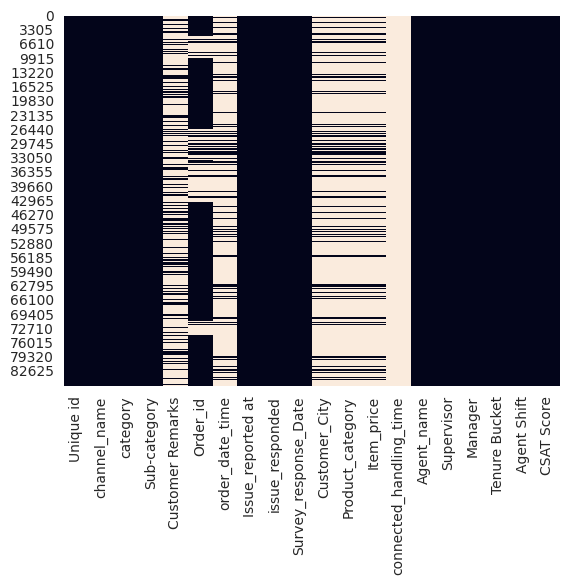

In [9]:
# Visualizing the missing values
# Checking Null Value by plotting Heatmap
sns.heatmap(dataset.isnull(), cbar=False)

### What did you know about your dataset?

The given dataset contains **85,907 customer service interaction records** with **20 features**, where the **CSAT Score** is the **target variable**. The dataset includes information related to **customer interactions**, **order details**, **support channels**, **product information**, and **agent details**.

From the initial exploration, the dataset contains **no duplicate values**, but there are **missing values** in columns such as **Customer Remarks**, **Order Date Time**, **Customer City**, **Product Category**, **Item Price**, and **Connected Handling Time**. These missing values will be handled appropriately during the **data preprocessing** stage before building the machine learning model.

## ***2. Understanding Your Variables***

In [10]:
# Dataset Columns
dataset.columns

Index(['Unique id', 'channel_name', 'category', 'Sub-category',
       'Customer Remarks', 'Order_id', 'order_date_time', 'Issue_reported at',
       'issue_responded', 'Survey_response_Date', 'Customer_City',
       'Product_category', 'Item_price', 'connected_handling_time',
       'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift',
       'CSAT Score'],
      dtype='object')

In [11]:
# Dataset Describe
dataset.describe(include='all')

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
count,85907,85907,85907,85907,28742,67675,17214,85907,85907,85907,17079,17196,17206.000000,242.000000,85907,85907,85907,85907,85907,85907.000000
unique,85907,3,12,57,18231,67675,13766,30923,30262,31,1782,9,NaN,NaN,1371,40,6,5,5,NaN
top,07c7a878-0d5a-42e0-97ef-de59abec0238,Inbound,Returns,Reverse Pickup Enquiry,Good,3230db30-f8da-4c44-8636-ec76d1d3d4f3,09/08/2023 11:55,13/08/2023 10:40,28/08/2023 00:00,28-Aug-23,HYDERABAD,Electronics,NaN,NaN,Wendy Taylor,Carter Park,John Smith,>90,Morning,NaN
freq,1,68142,44097,22389,1390,1,7,13,3378,3452,722,4706,NaN,NaN,429,4273,25261,30660,41426,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5660.774846,462.400826,NaN,NaN,NaN,NaN,NaN,4.242157
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12825.728411,246.295037,NaN,NaN,NaN,NaN,NaN,1.378903
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,1.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,392.000000,293.000000,NaN,NaN,NaN,NaN,NaN,4.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,979.000000,427.000000,NaN,NaN,NaN,NaN,NaN,5.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2699.750000,592.250000,NaN,NaN,NaN,NaN,NaN,5.000000


### Variables Description

* **Unique id                 :** Unique identifier for each customer service interaction.

* **channel_name              :** Customer support channel through which the issue was reported (e.g., Inbound, Outcall, Email).

* **category                  :** Main category of the customer issue.

* **Sub-category              :** Specific issue type within the main category.

* **Customer Remarks          :** Customer feedback or comments provided after the interaction.

* **Order_id                  :** Unique identifier for the customer's order.

* **order_date_time           :** Date and time when the customer placed the order.

* **Issue_reported at         :** Date and time when the customer reported the issue.

* **issue_responded           :** Date and time when the customer support team responded to the issue.

* **Survey_response_Date      :** Date when the customer submitted the CSAT survey.

* **Customer_City             :** City from which the customer raised the support request.

* **Product_category          :** Category of the product associated with the customer query.

* **Item_price                :** Price of the purchased product.

* **connected_handling_time   :** Total time spent by the support agent handling the customer issue.

* **Agent_name                :** Name of the customer support agent who handled the issue.

* **Supervisor                :** Supervisor responsible for monitoring the support agent.

* **Manager                   :** Manager overseeing the customer support operations.

* **Tenure Bucket             :** Experience level of the support agent based on tenure.

* **Agent Shift               :** Working shift of the support agent (Morning, Evening, Split, etc.).

* **CSAT Score                :** **Customer Satisfaction Score (Target Variable)** representing the customer's satisfaction rating.

### Check Unique Values for each variable.

In [12]:
# Check Unique Values for each variable.
for i in dataset.columns.tolist():
  print("No. of unique values in ",i,"is",dataset[i].nunique(),".")

No. of unique values in  Unique id is 85907 .
No. of unique values in  channel_name is 3 .
No. of unique values in  category is 12 .
No. of unique values in  Sub-category is 57 .
No. of unique values in  Customer Remarks is 18231 .
No. of unique values in  Order_id is 67675 .
No. of unique values in  order_date_time is 13766 .
No. of unique values in  Issue_reported at is 30923 .
No. of unique values in  issue_responded is 30262 .
No. of unique values in  Survey_response_Date is 31 .
No. of unique values in  Customer_City is 1782 .
No. of unique values in  Product_category is 9 .
No. of unique values in  Item_price is 2789 .
No. of unique values in  connected_handling_time is 211 .
No. of unique values in  Agent_name is 1371 .
No. of unique values in  Supervisor is 40 .
No. of unique values in  Manager is 6 .
No. of unique values in  Tenure Bucket is 5 .
No. of unique values in  Agent Shift is 5 .
No. of unique values in  CSAT Score is 5 .


## 3. ***Data Wrangling***

### Data Wrangling Code

In [13]:
# ==========================================
# Data Wrangling Code
# ==========================================

# Create a copy of the dataset for further analysis
df = dataset.copy()

# Display dataset shape
print(f"Dataset Shape: {df.shape}")

# Display first five records
df.head()

Dataset Shape: (85907, 20)


,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


In [14]:
# Display the distribution of the target variable
print("CSAT Score Distribution:")
print(df['CSAT Score'].value_counts().sort_index())

CSAT Score Distribution:
CSAT Score
1    11230
2     1283
3     2558
4    11219
5    59617
Name: count, dtype: int64


In [15]:
# Percentage distribution of CSAT Score
round(df['CSAT Score'].value_counts(normalize=True).sort_index()*100,2)

,proportion
CSAT Score,
1,13.07
2,1.49
3,2.98
4,13.06
5,69.40


In [16]:
# Number of customer interactions across different support channels
df['channel_name'].value_counts()

,count
channel_name,
Inbound,68142
Outcall,14742
Email,3023


In [17]:
# Number of issues in each category
df['category'].value_counts()

,count
category,
Returns,44097
Order Related,23215
Refund Related,4550
Product Queries,3692
Shopzilla Related,2792
Payments related,2327
Feedback,2294
Cancellation,2212
Offers & Cashback,480


In [18]:
# Customer interactions handled across different agent shifts
df['Agent Shift'].value_counts()

,count
Agent Shift,
Morning,41426
Evening,33677
Afternoon,5840
Split,3648
Night,1316


In [19]:
# Distribution of support agents based on experience
df['Tenure Bucket'].value_counts()

,count
Tenure Bucket,
>90,30660
On Job Training,25523
31-60,11665
0-30,11318
61-90,6741


### What all manipulations have you done and insights you found?

A copy of the original dataset was created for further analysis to preserve the raw data. The **CSAT Score** distribution and key categorical features such as **Channel Name**, **Category**, and **Tenure Bucket** were analyzed to better understand the dataset.

From the analysis, it was observed that **CSAT Score 5** is the most frequent rating, accounting for approximately **69.40%** of all customer interactions, indicating that most customers are satisfied with the support service. The majority of customer queries are handled through the **Inbound** support channel, while **Returns** and **Order Related** issues contribute to the highest number of support requests.

Additionally, most support agents belong to the **>90 days tenure bucket**, indicating that experienced agents handle a significant portion of customer interactions.

These initial findings provide a better understanding of the dataset and will help identify important patterns during the **data visualization**, **feature engineering**, and **machine learning** stages.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1 : Pie Chart on Dependent Variable (CSAT Score) (Univariate)

CSAT Score
5    59617
1    11230
4    11219
3     2558
2     1283
Name: count, dtype: int64



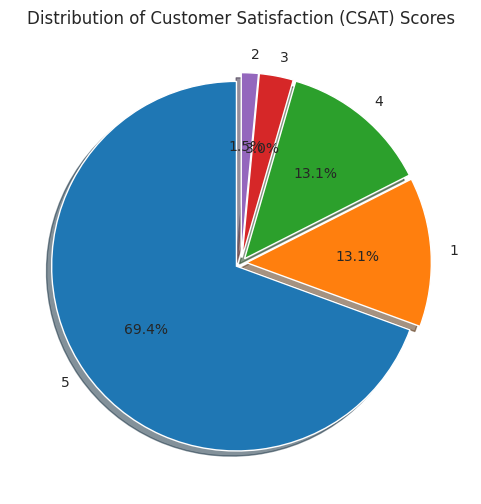

In [20]:
# ==========================================
# Chart - 1 : CSAT Score Distribution
# ==========================================

# Display CSAT Score counts
print(df['CSAT Score'].value_counts())
print()

# Plot Pie Chart
df['CSAT Score'].value_counts().plot(
    kind='pie',
    figsize=(6,6),
    autopct='%1.1f%%',
    startangle=90,
    shadow=True,
    explode=[0.03,0.03,0.03,0.03,0.03]
)

plt.title('Distribution of Customer Satisfaction (CSAT) Scores')
plt.ylabel('')
plt.show()

##### 1. Why did you pick the specific chart?

A **Pie Chart** is used to show the **proportion** of each **CSAT Score** in the dataset. Since **CSAT Score** is the **target variable** of this classification project, this chart helps understand the distribution of customer satisfaction levels and identify whether the dataset is **balanced** or **imbalanced**.

##### 2. What is/are the insight(s) found from the chart?

From the above chart, it can be observed that **CSAT Score 5** accounts for **69.4%** of the total customer interactions, making it the most frequent satisfaction rating. **CSAT Scores 1 and 4** each contribute approximately **13.1%**, while **Scores 2 (1.5%)** and **3 (3.0%)** have relatively fewer records. This indicates that the majority of customers are **highly satisfied** with Flipkart's customer support services.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights are valuable for both **business** and **model development**. The high percentage of **CSAT Score 5** indicates that Flipkart's customer support is generally performing well, leading to better **customer satisfaction**, **customer retention**, and **brand loyalty**. However, the distribution also reveals that the target variable is **imbalanced**, as lower CSAT scores occur much less frequently. This imbalance may affect the performance of the machine learning model by making it biased toward the majority class. Therefore, appropriate techniques for handling **class imbalance** should be considered during model training.

#### Chart - 2 - Channel Name Distribution (Univariate)

channel_name
Inbound    68142
Outcall    14742
Email       3023
Name: count, dtype: int64


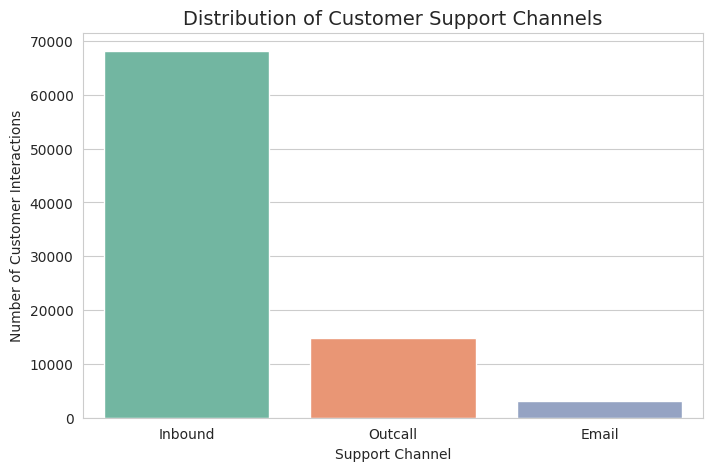

In [21]:
# ==========================================
# Chart - 2 : Distribution of Support Channels
# ==========================================

# Display support channel counts
print(df['channel_name'].value_counts())

# Plot Count Plot
plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    x='channel_name',
    order=df['channel_name'].value_counts().index,
    palette='Set2'
)

plt.title('Distribution of Customer Support Channels', fontsize=14)
plt.xlabel('Support Channel')
plt.ylabel('Number of Customer Interactions')

plt.show()

##### 1. Why did you pick the specific chart?

A **Count Plot** is used to visualize the **frequency distribution** of categorical variables. Since **Channel Name** is a categorical feature, this chart helps compare the number of customer interactions handled through each support channel and identify the most frequently used communication channel.

##### 2. What is/are the insight(s) found from the chart?

From the above chart, it is observed that the **Inbound** support channel handles the highest number of customer interactions, followed by **Outcall**, while **Email** receives the fewest customer requests. This indicates that customers primarily prefer contacting customer support through the **Inbound** channel, making it the most important communication medium for Flipkart's customer service operations.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can help improve **resource planning** and **customer support efficiency**. Since the majority of customer interactions occur through the **Inbound** channel, Flipkart should allocate sufficient agents and resources to maintain quick response times and high service quality. The relatively low usage of the **Email** channel may indicate that customers prefer faster communication methods, suggesting that continuous improvement of real-time support channels can further enhance the overall customer experience.

#### Chart - 3 - Category Distribution (Univariate)

category
Returns               44097
Order Related         23215
Refund Related         4550
Product Queries        3692
Shopzilla Related      2792
Payments related       2327
Feedback               2294
Cancellation           2212
Offers & Cashback       480
Others                   99
App/website              84
Onboarding related       65
Name: count, dtype: int64


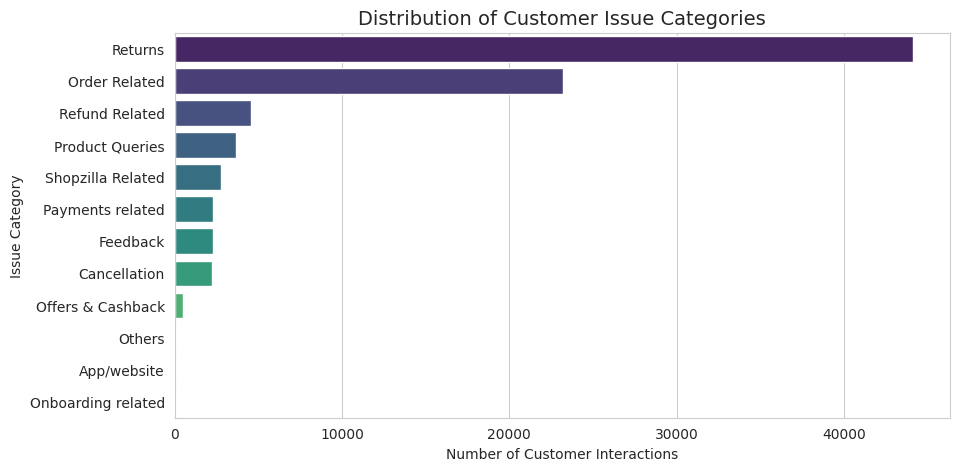

In [22]:
# ==========================================
# Chart - 3 : Distribution of Issue Categories
# ==========================================

# Display category counts
print(df['category'].value_counts())

# Plot Count Plot
plt.figure(figsize=(10,5))
sns.countplot(
    data=df,
    y='category',
    order=df['category'].value_counts().index,
    palette='viridis'
)

plt.title('Distribution of Customer Issue Categories', fontsize=14)
plt.xlabel('Number of Customer Interactions')
plt.ylabel('Issue Category')

plt.show()

##### 1. Why did you pick the specific chart?

A **Count Plot** is used to visualize the **frequency distribution** of categorical variables. Since **Issue Category** is a categorical feature, this chart helps compare the number of customer interactions across different issue categories and identify the categories that generate the highest customer support requests.

##### 2. What is/are the insight(s) found from the chart?

From the above chart, it is observed that **Returns** is the most common customer issue category, followed by **Order Related** issues. Categories such as **Refund Related**, **Product Queries**, **Shopzilla Related**, **Payments Related**, **Feedback**, and **Cancellation** have comparatively fewer customer interactions, while **Offers & Cashback**, **Others**, **App/website**, and **Onboarding Related** contribute only a very small number of cases. This indicates that most customer support requests are concentrated around **Returns** and **Order Related** services.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can help Flipkart improve its **customer support strategy**. Since **Returns** and **Order Related** issues account for the majority of customer interactions, the company should focus on improving the return process, order tracking, and issue resolution for these categories. Reducing problems in these high-volume categories can significantly improve **customer satisfaction**, reduce the workload on support agents, and enhance the overall customer experience.

#### Chart - 4 - Tenure Bucket Distribution (Univariate)

Tenure Bucket
>90                30660
On Job Training    25523
31-60              11665
0-30               11318
61-90               6741
Name: count, dtype: int64


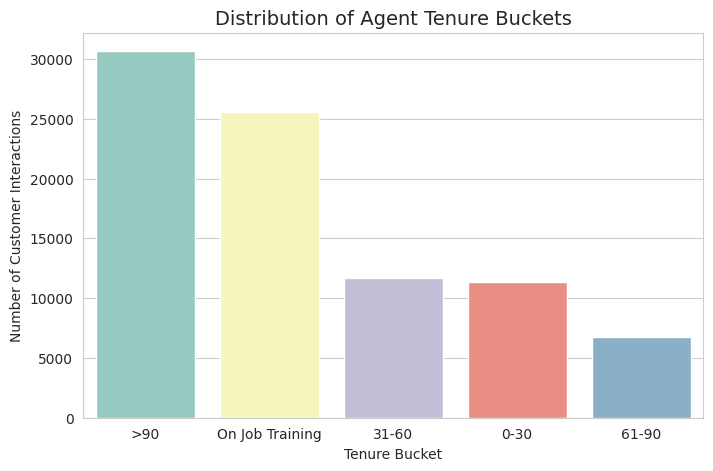

In [23]:
# ==========================================
# Chart - 4 : Distribution of Agent Tenure
# ==========================================

# Display tenure bucket counts
print(df['Tenure Bucket'].value_counts())

# Plot Count Plot
plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    x='Tenure Bucket',
    order=df['Tenure Bucket'].value_counts().index,
    palette='Set3'
)

plt.title('Distribution of Agent Tenure Buckets', fontsize=14)
plt.xlabel('Tenure Bucket')
plt.ylabel('Number of Customer Interactions')

plt.show()

##### 1. Why did you pick the specific chart?

A **Count Plot** is used to visualize the **distribution** of categorical variables. Since **Tenure Bucket** represents the experience level of customer support agents, this chart helps understand how customer interactions are distributed among agents with different levels of experience.

##### 2. What is/are the insight(s) found from the chart?

From the above chart, it is observed that agents with **more than 90 days of experience (>90)** handle the highest number of customer interactions, followed by agents in the **On Job Training** category. Agents with **31–60**, **0–30**, and **61–90** days of experience handle comparatively fewer interactions. This indicates that experienced agents are responsible for managing a significant portion of customer support requests.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can support better **workforce planning** and **agent allocation**. Since experienced agents (**>90 days**) handle the majority of customer interactions, Flipkart can continue assigning complex issues to them while providing additional training and mentorship to less experienced agents. This approach can improve **service quality**, **reduce issue resolution time**, and enhance **overall customer satisfaction**.

#### Chart - 5 - Agent Shift Distribution (Univariate)

Agent Shift
Morning      41426
Evening      33677
Afternoon     5840
Split         3648
Night         1316
Name: count, dtype: int64


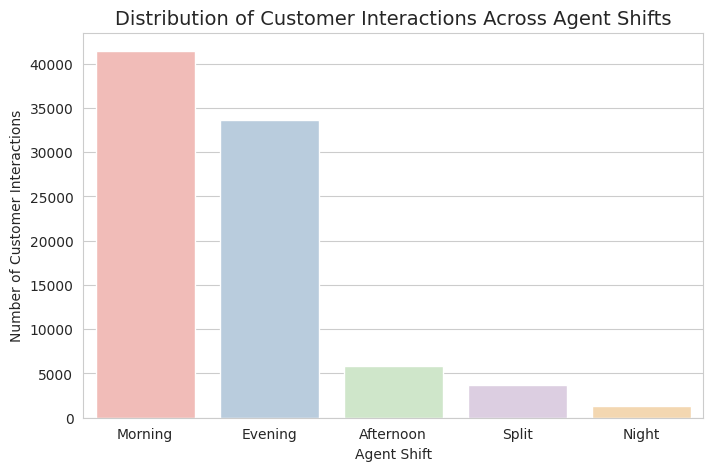

In [24]:
# ==========================================
# Chart - 5 : Distribution of Agent Shifts
# ==========================================

# Display agent shift counts
print(df['Agent Shift'].value_counts())

# Plot Count Plot
plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    x='Agent Shift',
    order=df['Agent Shift'].value_counts().index,
    palette='Pastel1'
)

plt.title('Distribution of Customer Interactions Across Agent Shifts', fontsize=14)
plt.xlabel('Agent Shift')
plt.ylabel('Number of Customer Interactions')

plt.show()

##### 1. Why did you pick the specific chart?

A **Count Plot** is used to visualize the **distribution** of categorical variables. Since **Agent Shift** is a categorical feature, this chart helps compare the number of customer interactions handled during different work shifts and identifies the busiest support periods.

##### 2. What is/are the insight(s) found from the chart?

From the above chart, it is observed that the **Morning** shift handles the highest number of customer interactions, followed by the **Evening** shift. In contrast, the **Afternoon**, **Split**, and **Night** shifts manage significantly fewer customer requests. This indicates that customer support demand is highest during the **Morning** and **Evening** hours.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can help optimize **workforce scheduling** and **resource allocation**. Since the **Morning** and **Evening** shifts receive the highest customer interactions, Flipkart should ensure adequate staffing during these periods to minimize customer waiting time and improve service quality. Monitoring the lower-volume shifts can also help identify opportunities to balance workloads and utilize resources more efficiently, ultimately enhancing **customer satisfaction** and **operational efficiency**.

#### Chart - 6 - Channel Name vs CSAT Score (Bivariate Analysis)

CSAT Score       1     2     3     4      5
channel_name                               
Email          636    64   102   388   1833
Inbound       8745  1011  2033  8934  47419
Outcall       1849   208   423  1897  10365


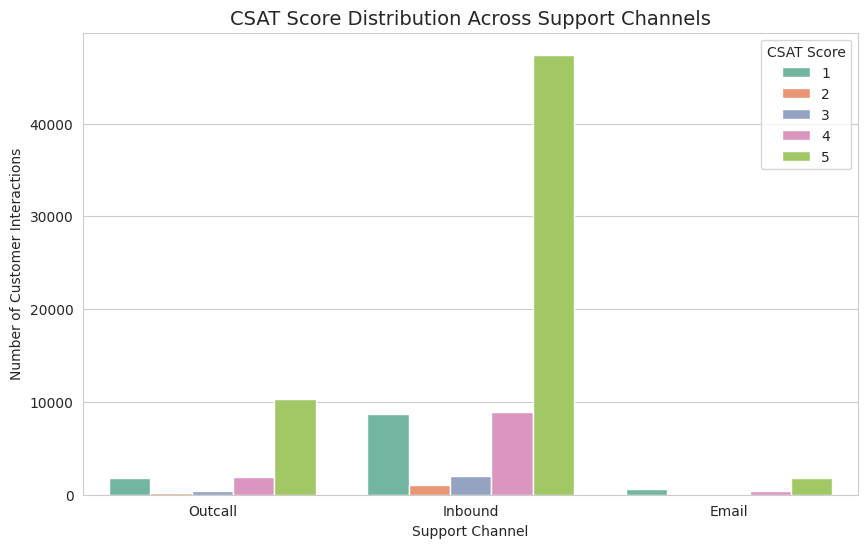

In [25]:
# ==========================================
# Chart - 6 : Channel Name vs CSAT Score
# ==========================================

# Display cross-tabulation
channel_csat = pd.crosstab(df['channel_name'], df['CSAT Score'])
print(channel_csat)

# Plot grouped bar chart
plt.figure(figsize=(10,6))
sns.countplot(
    data=df,
    x='channel_name',
    hue='CSAT Score',
    palette='Set2'
)

plt.title('CSAT Score Distribution Across Support Channels', fontsize=14)
plt.xlabel('Support Channel')
plt.ylabel('Number of Customer Interactions')
plt.legend(title='CSAT Score')

plt.show()

##### 1. Why did you pick the specific chart?

A **grouped count plot** is used to compare the distribution of **CSAT Scores** across different **customer support channels**. This visualization helps identify whether customer satisfaction varies depending on the communication channel and allows for an easy comparison of satisfaction levels among **Inbound**, **Outcall**, and **Email** support.

##### 2. What is/are the insight(s) found from the chart?

From the above chart, it is observed that the **Inbound** channel handles the largest number of customer interactions across all **CSAT Scores**, with **CSAT Score 5** being the most common rating. The **Outcall** channel also records a high number of satisfied customers but handles significantly fewer interactions than Inbound. The **Email** channel has the lowest interaction volume, with most customers also giving a **CSAT Score of 5**. Overall, **CSAT Score 5** dominates across all support channels, indicating a generally high level of customer satisfaction regardless of the communication channel.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

From the above chart, it is observed that the **Inbound** channel handles the largest number of customer interactions across all **CSAT Scores**, with **CSAT Score 5** being the most common rating. The **Outcall** channel also records a high number of satisfied customers but handles significantly fewer interactions than Inbound. The **Email** channel has the lowest interaction volume, with most customers also giving a **CSAT Score of 5**. Overall, **CSAT Score 5** dominates across all support channels, indicating a generally high level of customer satisfaction regardless of the communication channel.

#### Chart - 7- Category vs CSAT Score (Bivariate Analysis)

CSAT Score             1    2     3     4      5
category                                        
App/website           11    0     0     6     67
Cancellation         435   40    58   257   1422
Feedback             351   35    76   269   1563
Offers & Cashback     69    2    11    75    323
Onboarding related     9    1     2     5     48
Order Related       3730  422   826  3147  15090
Others                29    4     7    13     46
Payments related     238   35    69   307   1678
Product Queries      583   91   179   582   2257
Refund Related       618   65   121   609   3137
Returns             4824  549  1134  5613  31977
Shopzilla Related    333   39    75   336   2009


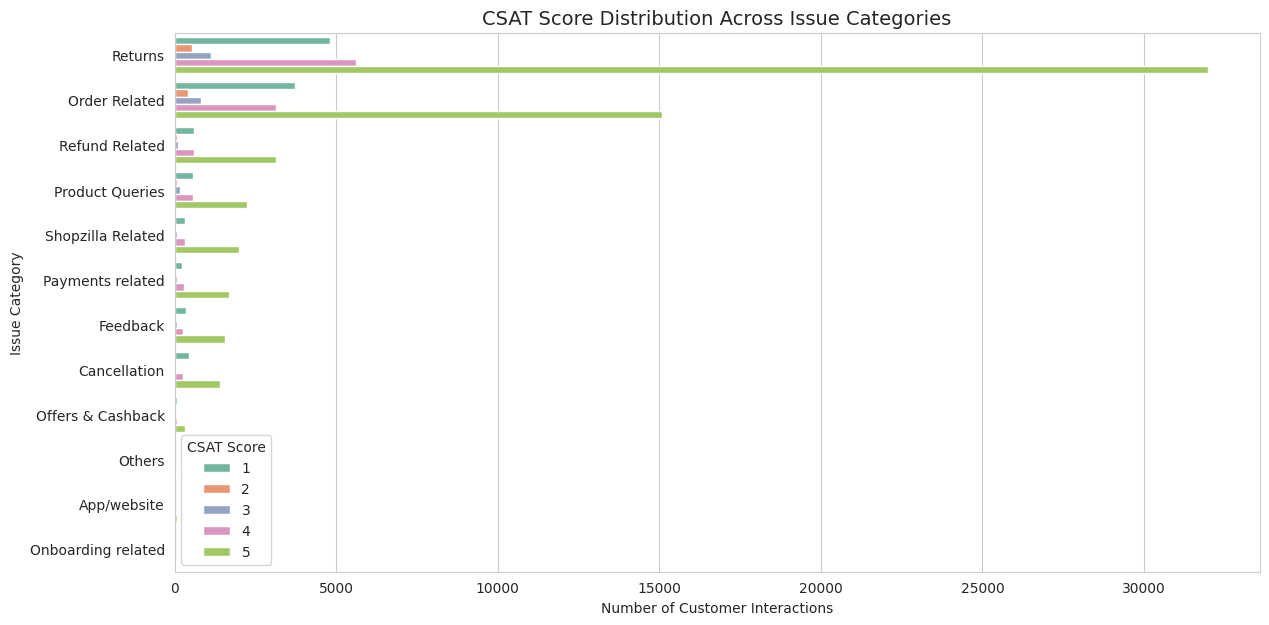

In [26]:
# ==========================================
# Chart - 7 : Category vs CSAT Score
# ==========================================

# Display cross-tabulation
category_csat = pd.crosstab(df['category'], df['CSAT Score'])
print(category_csat)

# Plot grouped bar chart
plt.figure(figsize=(14,7))
sns.countplot(
    data=df,
    y='category',
    hue='CSAT Score',
    order=df['category'].value_counts().index,
    palette='Set2'
)

plt.title('CSAT Score Distribution Across Issue Categories', fontsize=14)
plt.xlabel('Number of Customer Interactions')
plt.ylabel('Issue Category')
plt.legend(title='CSAT Score')

plt.show()

##### 1. Why did you pick the specific chart?

A **grouped count plot** is used to compare the distribution of **CSAT Scores** across different **issue categories**. This chart helps identify which categories receive higher or lower customer satisfaction ratings and enables a direct comparison of customer satisfaction for each type of service request.

##### 2. What is/are the insight(s) found from the chart?

From the above chart, it is observed that **Returns** and **Order Related** issues account for the highest number of customer interactions across all **CSAT Scores**. In almost every issue category, **CSAT Score 5** is the most common rating, indicating that most customers are satisfied with the support provided. However, **Returns** also records the highest number of low satisfaction ratings (**CSAT Score 1**), suggesting that return-related issues contribute significantly to customer dissatisfaction due to their high interaction volume.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can help Flipkart prioritize improvements in its **customer support operations**. Since **Returns** and **Order Related** issues generate the largest number of customer interactions, improving the efficiency of these processes can have the greatest impact on overall customer satisfaction. Additionally, the relatively higher number of **CSAT Score 1** ratings in the **Returns** category highlights an area that requires special attention. Addressing delays, simplifying return procedures, and improving communication during the return process can reduce customer dissatisfaction and strengthen customer loyalty.

#### Chart - 8 - Tenure Bucket vs CSAT Score (Bivariate Analysis)

CSAT Score          1    2    3     4      5
Tenure Bucket                               
0-30             1417  175  348  1500   7878
31-60            1390  170  336  1468   8301
61-90             735   85  189   832   4900
>90              3882  411  834  3855  21678
On Job Training  3806  442  851  3564  16860


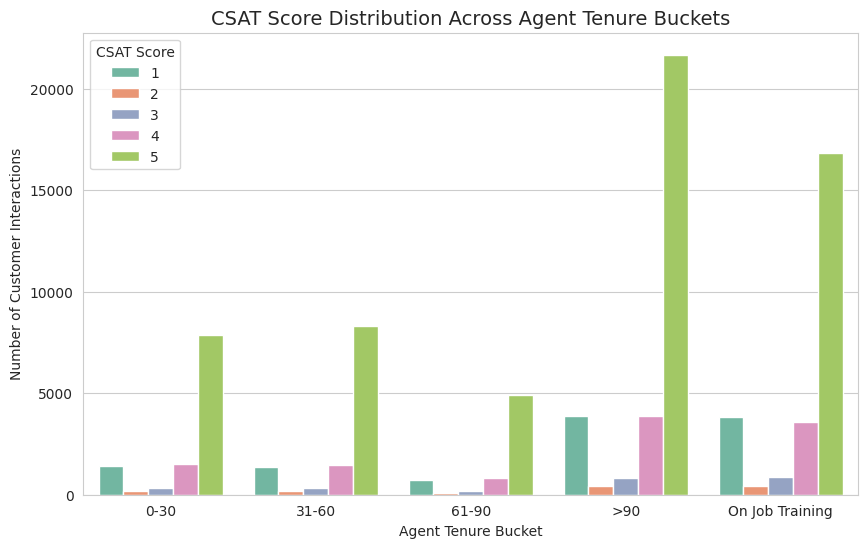

In [27]:
# ==========================================
# Chart - 8 : Tenure Bucket vs CSAT Score
# ==========================================

# Display cross-tabulation
tenure_csat = pd.crosstab(df['Tenure Bucket'], df['CSAT Score'])
print(tenure_csat)

# Plot grouped count plot
plt.figure(figsize=(10,6))
sns.countplot(
    data=df,
    x='Tenure Bucket',
    hue='CSAT Score',
    order=['0-30', '31-60', '61-90', '>90', 'On Job Training'],
    palette='Set2'
)

plt.title('CSAT Score Distribution Across Agent Tenure Buckets', fontsize=14)
plt.xlabel('Agent Tenure Bucket')
plt.ylabel('Number of Customer Interactions')
plt.legend(title='CSAT Score')

plt.show()

##### 1. Why did you pick the specific chart?

A **grouped count plot** is used to compare the distribution of **CSAT Scores** across different **Agent Tenure Buckets**. This chart helps analyze whether the experience level of customer support agents has any relationship with customer satisfaction and enables comparison of satisfaction levels across different tenure groups.

##### 2. What is/are the insight(s) found from the chart?

From the above chart, it is observed that **CSAT Score 5** is the most frequent rating across all **Tenure Buckets**, indicating consistently high customer satisfaction regardless of agent experience. Agents with **more than 90 days (>90)** of experience handle the highest number of customer interactions and also receive the largest number of **CSAT Score 5** ratings. The **On Job Training** group also records a considerable number of high satisfaction scores, suggesting that newly trained agents are able to deliver satisfactory customer support.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can help improve **workforce management** and **training strategies**. Since experienced agents (**>90 days**) handle the highest volume of interactions while maintaining a large number of positive satisfaction scores, they can be assigned more complex customer issues and can mentor less experienced agents. The strong performance of the **On Job Training** group also indicates that the existing training process is effective. Continuing to invest in agent training and knowledge sharing can further improve service quality and customer satisfaction.

#### Chart - 9 - Agent Shift vs CSAT Score (Bivariate Analysis)

CSAT Score      1    2     3     4      5
Agent Shift                              
Afternoon     700   98   150   739   4153
Evening      4139  484   988  4386  23680
Morning      5895  630  1292  5522  28087
Night         165   25    36   129    961
Split         331   46    92   443   2736


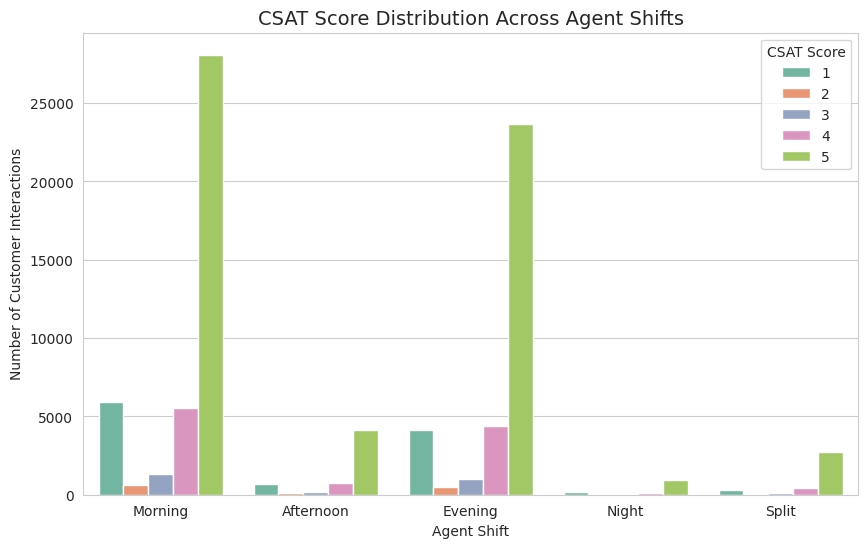

In [28]:
# ==========================================
# Chart - 9 : Agent Shift vs CSAT Score
# ==========================================

# Display cross-tabulation
shift_csat = pd.crosstab(df['Agent Shift'], df['CSAT Score'])
print(shift_csat)

# Plot grouped count plot
plt.figure(figsize=(10,6))
sns.countplot(
    data=df,
    x='Agent Shift',
    hue='CSAT Score',
    order=['Morning', 'Afternoon', 'Evening', 'Night', 'Split'],
    palette='Set2'
)

plt.title('CSAT Score Distribution Across Agent Shifts', fontsize=14)
plt.xlabel('Agent Shift')
plt.ylabel('Number of Customer Interactions')
plt.legend(title='CSAT Score')

plt.show()

##### 1. Why did you pick the specific chart?

A **grouped count plot** is used to compare the distribution of **CSAT Scores** across different **Agent Shifts**. This chart helps analyze whether customer satisfaction varies across work shifts and identifies which shift handles the highest number of satisfied and dissatisfied customers.

##### 2. What is/are the insight(s) found from the chart?

From the above chart, it is observed that the **Morning** shift handles the highest number of customer interactions and records the largest number of **CSAT Score 5** ratings, followed by the **Evening** shift. The **Afternoon**, **Night**, and **Split** shifts handle comparatively fewer customer interactions, but **CSAT Score 5** remains the most common rating across all shifts. This indicates that high customer satisfaction is consistently maintained regardless of the working shift.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can help optimize **shift scheduling** and **resource allocation**. Since the **Morning** and **Evening** shifts receive the highest customer interaction volumes, Flipkart should ensure sufficient staffing and experienced agents are available during these periods to maintain service quality. The consistent presence of **CSAT Score 5** across all shifts also indicates that customer support performance remains stable throughout the day, reflecting an effective customer service operation.

#### Chart - 10 - Product Category vs CSAT Score (Bivariate Analysis)

CSAT Score                     1   2    3    4     5
Product_category                                    
Affiliates                    23   3    3   25   112
Books & General merchandise  584  74  115  433  2117
Electronics                  852  85  167  593  3009
Furniture                    136   7   17   51   260
GiftCard                      11   0    0    2    13
Home                         269  24   37  166   832
Home Appliences              350  22   40  141   747
LifeStyle                    654  73  131  571  2689
Mobile                       486  44   58  188   982


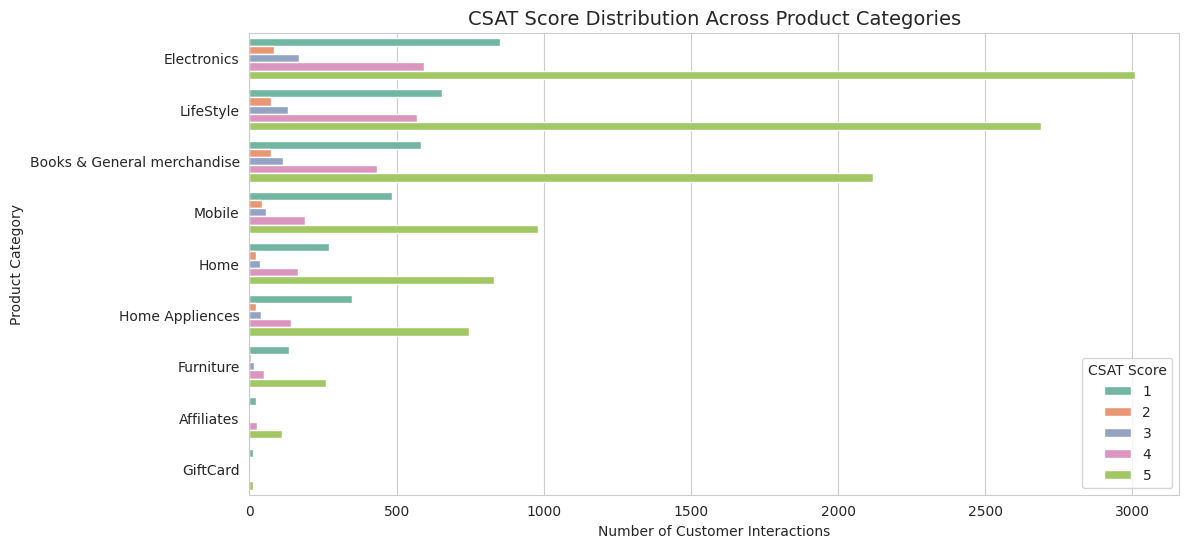

In [29]:
# ==========================================
# Chart - 10 : Product Category vs CSAT Score
# ==========================================

# Display cross-tabulation
product_csat = pd.crosstab(df['Product_category'], df['CSAT Score'])
print(product_csat)

# Plot grouped count plot
plt.figure(figsize=(12,6))
sns.countplot(
    data=df.dropna(subset=['Product_category']),
    y='Product_category',
    hue='CSAT Score',
    order=df['Product_category'].value_counts().index,
    palette='Set2'
)

plt.title('CSAT Score Distribution Across Product Categories', fontsize=14)
plt.xlabel('Number of Customer Interactions')
plt.ylabel('Product Category')
plt.legend(title='CSAT Score')

plt.show()

##### 1. Why did you pick the specific chart?

A **grouped count plot** is used to compare the distribution of **CSAT Scores** across different **Product Categories**. This chart helps identify whether customer satisfaction varies by product category and highlights which product categories receive the highest number of customer interactions and satisfaction ratings.

##### 2. What is/are the insight(s) found from the chart?

From the above chart, it is observed that **Electronics**, **LifeStyle**, and **Books & General Merchandise** generate the highest number of customer interactions. Across all product categories, **CSAT Score 5** is the most frequent rating, indicating a high level of customer satisfaction. However, these high-volume product categories also record a noticeable number of lower satisfaction ratings (**CSAT Score 1**), suggesting that although most customers are satisfied, these categories contribute the most to customer complaints due to their larger interaction volume.

##### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can help Flipkart prioritize improvements in **high-demand product categories**. Since **Electronics**, **LifeStyle**, and **Books & General Merchandise** account for the largest share of customer interactions, improving product quality, delivery experience, and issue resolution for these categories can significantly enhance overall customer satisfaction. Monitoring categories with relatively higher numbers of low **CSAT Scores** can also help identify recurring issues and support targeted business improvements.

#### Chart - 11 - Distribution of Item Price (Univariate Analysis)

count     17206.000000
mean       5660.774846
std       12825.728411
min           0.000000
25%         392.000000
50%         979.000000
75%        2699.750000
max      164999.000000
Name: Item_price, dtype: float64


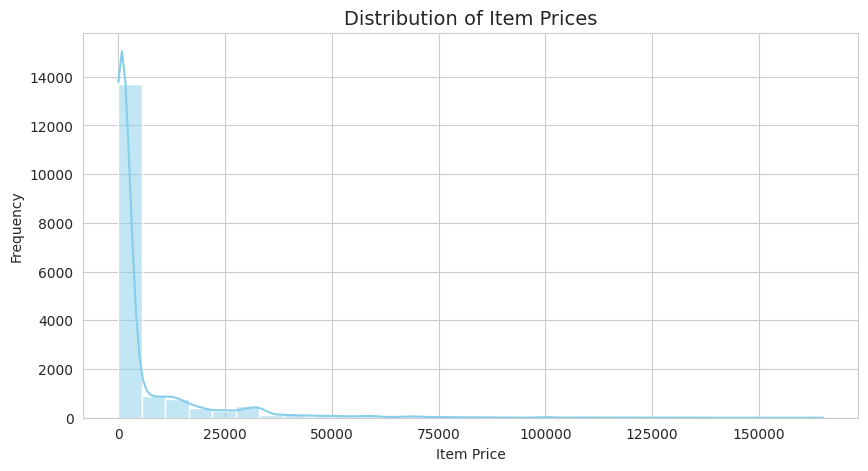

In [30]:
# ==========================================
# Chart - 11 : Distribution of Item Price
# ==========================================

# Display summary statistics
print(df['Item_price'].describe())

# Plot Histogram
plt.figure(figsize=(10,5))
sns.histplot(
    data=df,
    x='Item_price',
    bins=30,
    kde=True,
    color='skyblue'
)

plt.title('Distribution of Item Prices', fontsize=14)
plt.xlabel('Item Price')
plt.ylabel('Frequency')

plt.show()

##### 1. Why did you pick the specific chart?

A **Histogram with a Kernel Density Estimate (KDE)** is used to understand the **distribution** of a numerical variable. Since **Item Price** is a continuous feature, this chart helps visualize the spread of product prices, identify the concentration of observations, and detect the presence of **skewness** or **outliers**.

##### 2. What is/are the insight(s) found from the chart?

From the above chart, it is observed that the majority of purchased products have **lower item prices**, with the frequency decreasing as the price increases. The distribution is **highly right-skewed**, indicating that only a small number of products belong to the high-price range. The presence of a long right tail also suggests the existence of **high-value products** or **potential outliers** in the dataset.

#### Chart - 12 - Item Price vs CSAT Score (Bivariate Analysis)

              count         mean           std   min    25%     50%       75%  \
CSAT Score                                                                      
1            3368.0  8848.801069  16126.778073   1.0  450.5  1351.0  10999.00   
2             332.0  6071.716867  12547.417460  33.0  399.0   890.0   2823.25   
3             568.0  6212.457746  13710.765002   1.0  399.0   977.0   3182.50   
4            2172.0  5206.325967  13108.040326   1.0  369.0   874.0   1999.00   
5           10766.0  4713.347947  11315.066297   0.0  381.0   899.0   2072.75   

                 max  
CSAT Score            
1           164999.0  
2            69997.0  
3           151990.0  
4           144990.0  
5           134999.0  


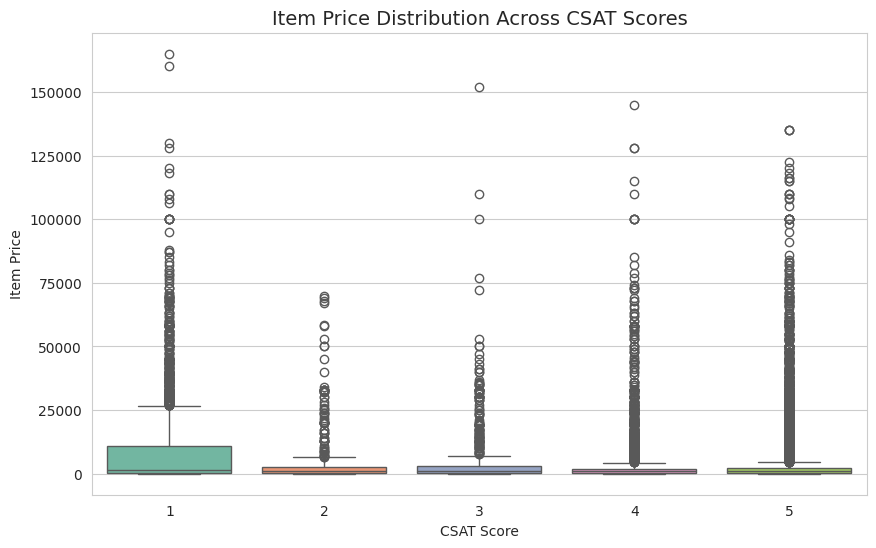

In [31]:
# ==========================================
# Chart - 12 : Item Price vs CSAT Score
# ==========================================

# Display summary statistics
print(df.groupby('CSAT Score')['Item_price'].describe())

# Plot Box Plot
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df,
    x='CSAT Score',
    y='Item_price',
    palette='Set2'
)

plt.title('Item Price Distribution Across CSAT Scores', fontsize=14)
plt.xlabel('CSAT Score')
plt.ylabel('Item Price')

plt.show()

##### 1. Why did you pick the specific chart?

A **Box Plot** is used to compare the distribution of a **numerical variable** across different **categorical groups**. Since **Item Price** is a numerical feature and **CSAT Score** is a categorical target variable, this chart helps visualize the spread of item prices, compare the median values across satisfaction levels, and identify the presence of **outliers**.

##### 2. What is/are the insight(s) found from the chart?

From the above chart, it is observed that the **median item price** is relatively similar across all **CSAT Score** categories, indicating that customer satisfaction is not strongly influenced by the price of the purchased product. The chart also reveals a large number of **high-price outliers** in every CSAT category, suggesting that both low-priced and premium products receive a wide range of customer satisfaction ratings.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights indicate that **product price alone is not a major factor influencing customer satisfaction**. Since customers across all price ranges provide similar satisfaction ratings, Flipkart should focus on improving other aspects such as **service quality**, **issue resolution time**, and **customer support experience** rather than relying solely on product pricing. Additionally, the presence of many **high-value outliers** highlights the importance of providing consistent support for premium products to maintain customer trust.

#### Chart - 13 - Correlation Heatmap (Multivariate Analysis)

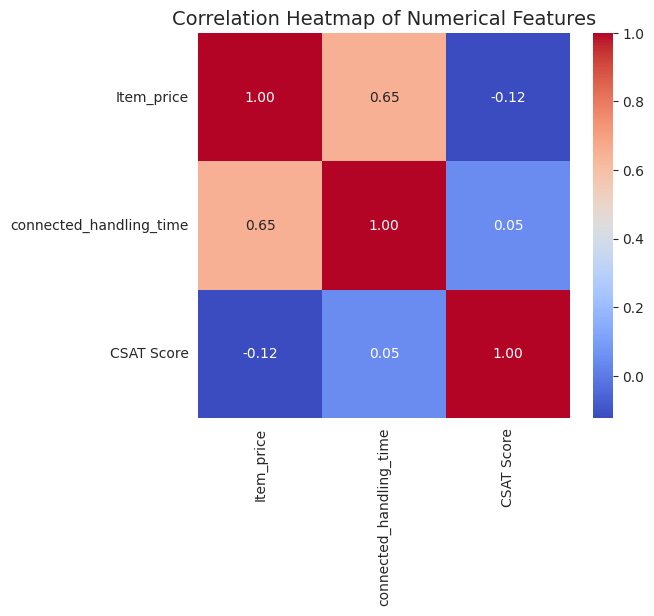

In [32]:
# ==========================================
# Chart - 13 : Correlation Heatmap
# ==========================================

# Select numerical features
numerical_df = df[['Item_price', 'connected_handling_time', 'CSAT Score']]

# Plot Correlation Heatmap
plt.figure(figsize=(6,5))
sns.heatmap(
    numerical_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap of Numerical Features', fontsize=14)

plt.show()

##### 1. Why did you pick the specific chart?

A **Correlation Heatmap** is used to visualize the **strength and direction of the relationship** between numerical variables. It helps identify whether features are highly correlated with each other or with the **target variable (CSAT Score)**, which is useful during **feature selection** and **model building**.

##### 2. What is/are the insight(s) found from the chart?

From the above heatmap, it is observed that **Item Price** and **Connected Handling Time** have a **moderate positive correlation (0.65)**, indicating that higher-priced products generally require more handling time. However, both features show **very weak correlation** with the **CSAT Score**, with **Item Price (-0.12)** having a weak negative relationship and **Connected Handling Time (0.05)** having an almost negligible positive relationship. This suggests that these numerical features alone are not strong predictors of customer satisfaction.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights are valuable for **feature selection** and **business decision-making**. Since **Item Price** and **Connected Handling Time** have only a weak relationship with **CSAT Score**, customer satisfaction is likely influenced more by other factors such as **support channel**, **issue category**, **agent experience**, and **service quality**. This indicates that improving operational processes and customer support services may have a greater impact on customer satisfaction than focusing solely on product price or handling time.

              count         mean           std   min    25%     50%       75%  \
CSAT Score                                                                      
1            3368.0  8848.801069  16126.778073   1.0  450.5  1351.0  10999.00   
2             332.0  6071.716867  12547.417460  33.0  399.0   890.0   2823.25   
3             568.0  6212.457746  13710.765002   1.0  399.0   977.0   3182.50   
4            2172.0  5206.325967  13108.040326   1.0  369.0   874.0   1999.00   
5           10766.0  4713.347947  11315.066297   0.0  381.0   899.0   2072.75   

                 max  
CSAT Score            
1           164999.0  
2            69997.0  
3           151990.0  
4           144990.0  
5           134999.0  


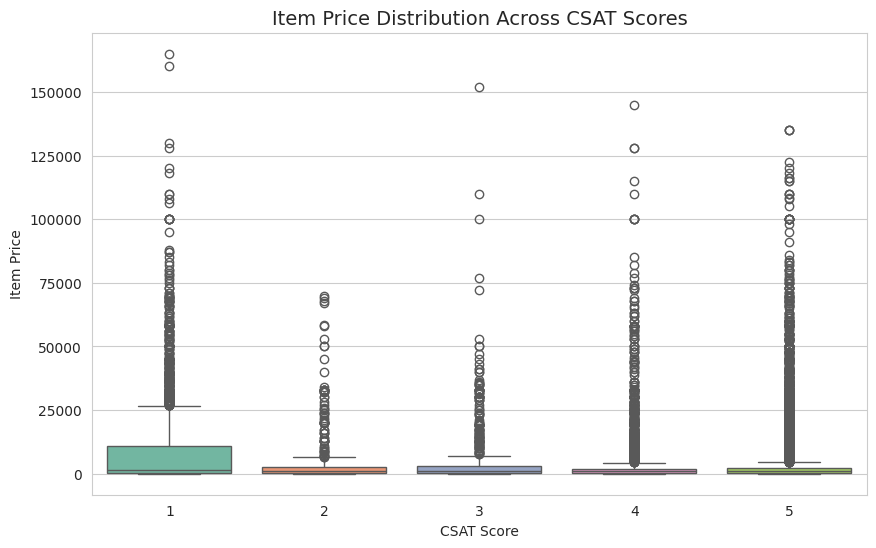

In [33]:
# ==========================================
# Chart - 12 : Item Price vs CSAT Score
# ==========================================

# Display summary statistics
print(df.groupby('CSAT Score')['Item_price'].describe())

# Plot Box Plot
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df,
    x='CSAT Score',
    y='Item_price',
    palette='Set2'
)

plt.title('Item Price Distribution Across CSAT Scores', fontsize=14)
plt.xlabel('CSAT Score')
plt.ylabel('Item Price')

plt.show()

##### 1. Why did you pick the specific chart?

A **Box Plot** is used to compare the distribution of a **numerical variable** across different **categorical groups**. Since **Item Price** is a numerical feature and **CSAT Score** is a categorical target variable, this chart helps visualize the spread of item prices, compare the median values across satisfaction levels, and identify the presence of **outliers**.

##### 2. What is/are the insight(s) found from the chart?

From the above chart, it is observed that the **median item price** is relatively similar across all **CSAT Score** categories, indicating that customer satisfaction is not strongly influenced by the price of the purchased product. The chart also reveals a large number of **high-price outliers** in every CSAT category, suggesting that both low-priced and premium products receive a wide range of customer satisfaction ratings.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights indicate that **product price alone is not a major factor influencing customer satisfaction**. Since customers across all price ranges provide similar satisfaction ratings, Flipkart should focus on improving other aspects such as **service quality**, **issue resolution time**, and **customer support experience** rather than relying solely on product pricing. Additionally, the presence of many **high-value outliers** highlights the importance of providing consistent support for premium products to maintain customer trust.

## ***5. Hypothesis Testing***

### Based on the **Exploratory Data Analysis (EDA)**, three hypotheses have been formulated to statistically validate the relationships observed in the dataset. Appropriate statistical tests are performed to determine whether the observed patterns are statistically significant.

The following hypotheses are tested:

1. **Customer Satisfaction (CSAT Score) is associated with the Customer Support Channel.**

2. **Customer Satisfaction (CSAT Score) is associated with the Issue Category.**

3. **The average Item Price differs across different CSAT Score groups.**

In [34]:
# Import Statistical Libraries
from scipy.stats import chi2_contingency
from scipy.stats import f_oneway

In [35]:
# Function to interpret hypothesis test result
def conclusion(p_value):
    significance_level = 0.05

    if p_value < significance_level:
        print(f"Null Hypothesis Rejected (p-value = {p_value:.6f})")
    else:
        print(f"Failed to Reject the Null Hypothesis (p-value = {p_value:.6f})")

### Hypothetical Statement - 1
Customer Satisfaction (CSAT Score) is associated with the Customer Support Channel.

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**Null Hypothesis (H₀):** There is no significant association between Customer Support Channel and CSAT Score.

**Alternate Hypothesis (H₁):** There is a significant association between Customer Support Channel and CSAT Score.

**Statistical Test Used:** Chi-Square Test of Independence

#### 2. Perform an appropriate statistical test.

In [36]:
# Create Contingency Table
channel_csat = pd.crosstab(df['channel_name'], df['CSAT Score'])

# Display Contingency Table
channel_csat

CSAT Score,1,2,3,4,5
channel_name,,,,,
Email,636,64,102,388,1833
Inbound,8745,1011,2033,8934,47419
Outcall,1849,208,423,1897,10365


In [37]:
# Perform Chi-Square Test

chi2, p_value, dof, expected = chi2_contingency(channel_csat)

print("Chi-Square Statistic :", chi2)
print("Degrees of Freedom   :", dof)
print("P-Value              :", p_value)

print()

conclusion(p_value)

Chi-Square Statistic : 199.91187547222546
Degrees of Freedom   : 8
P-Value              : 6.66900152078005e-39

Null Hypothesis Rejected (p-value = 0.000000)


##### Which statistical test have you done to obtain P-Value?

A **Chi-Square Test of Independence** was performed to determine whether there is a significant association between **Customer Support Channel** and **CSAT Score**. The obtained **p-value (6.669 × 10⁻³⁹)** is much smaller than the significance level of **0.05**. Therefore, the **Null Hypothesis is rejected**, indicating that **Customer Support Channel and CSAT Score are significantly associated**. This suggests that the support channel through which customers interact has a statistically significant relationship with customer satisfaction.

##### Why did you choose the specific statistical test?

The **Chi-Square Test of Independence** was chosen because both **Customer Support Channel** and **CSAT Score** are **categorical variables**. This statistical test is specifically designed to examine whether two categorical variables are independent or significantly associated. Since the objective is to determine whether customer satisfaction varies across different support channels, the Chi-Square Test is the most appropriate method for this analysis.

### Hypothetical Statement - 2
Customer Satisfaction (CSAT Score) is associated with the Issue Category.

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**Null Hypothesis (H₀):** There is no significant association between Issue Category and CSAT Score.

**Alternate Hypothesis (H₁):** There is a significant association between Issue Category and CSAT Score.

**Statistical Test Used:** Chi-Square Test of Independence

#### 2. Perform an appropriate statistical test.

In [38]:
# Create Contingency Table
category_csat = pd.crosstab(df['category'], df['CSAT Score'])

# Display Contingency Table
category_csat

CSAT Score,1,2,3,4,5
category,,,,,
App/website,11,0,0,6,67
Cancellation,435,40,58,257,1422
Feedback,351,35,76,269,1563
Offers & Cashback,69,2,11,75,323
Onboarding related,9,1,2,5,48
Order Related,3730,422,826,3147,15090
Others,29,4,7,13,46
Payments related,238,35,69,307,1678
Product Queries,583,91,179,582,2257


In [39]:
# Perform Chi-Square Test

chi2, p_value, dof, expected = chi2_contingency(category_csat)

print("Chi-Square Statistic :", chi2)
print("Degrees of Freedom   :", dof)
print("P-Value              :", p_value)

print()

conclusion(p_value)

Chi-Square Statistic : 860.8854632341543
Degrees of Freedom   : 44
P-Value              : 4.860086707285712e-152

Null Hypothesis Rejected (p-value = 0.000000)


##### Which statistical test have you done to obtain P-Value?

A **Chi-Square Test of Independence** was performed to examine whether there is a significant association between **Issue Category** and **CSAT Score**. The obtained **p-value (4.860 × 10⁻¹⁵²)** is significantly smaller than the significance level of **0.05**. Therefore, the **Null Hypothesis is rejected**, indicating that **Issue Category and CSAT Score are significantly associated**. This suggests that different types of customer issues have a statistically significant impact on customer satisfaction.

##### Why did you choose the specific statistical test?

The **Chi-Square Test of Independence** was selected because both **Issue Category** and **CSAT Score** are **categorical variables**. This test is appropriate for determining whether there is a significant relationship between two categorical variables. Since the objective is to analyze whether customer satisfaction differs across various issue categories, the Chi-Square Test is the most suitable statistical method for this analysis.

### Hypothetical Statement - 3
The average Item Price is the same across different CSAT Score groups.

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**Null Hypothesis (H₀):** The mean Item Price is the same across all CSAT Score groups.

**Alternate Hypothesis (H₁):** At least one CSAT Score group has a different mean Item Price.

**Statistical Test Used:** One-Way ANOVA

#### 2. Perform an appropriate statistical test.

In [40]:
# Display mean Item Price for each CSAT Score
df.groupby('CSAT Score')['Item_price'].mean()

,Item_price
CSAT Score,
1,8848.801069
2,6071.716867
3,6212.457746
4,5206.325967
5,4713.347947


In [41]:
# Create groups for ANOVA

csat_1 = df[df['CSAT Score'] == 1]['Item_price'].dropna()
csat_2 = df[df['CSAT Score'] == 2]['Item_price'].dropna()
csat_3 = df[df['CSAT Score'] == 3]['Item_price'].dropna()
csat_4 = df[df['CSAT Score'] == 4]['Item_price'].dropna()
csat_5 = df[df['CSAT Score'] == 5]['Item_price'].dropna()

# Perform One-Way ANOVA
f_statistic, p_value = f_oneway(csat_1, csat_2, csat_3, csat_4, csat_5)

print("F-Statistic :", f_statistic)
print("P-Value     :", p_value)

print()

conclusion(p_value)

F-Statistic : 68.80669917347767
P-Value     : 6.971377612769249e-58

Null Hypothesis Rejected (p-value = 0.000000)


##### Which statistical test have you done to obtain P-Value?

A **One-Way ANOVA (Analysis of Variance)** test was performed to determine whether the **average Item Price** differs across the different **CSAT Score** groups. The obtained **p-value (6.971 × 10⁻⁵⁸)** is much smaller than the significance level of **0.05**. Therefore, the **Null Hypothesis is rejected**, indicating that the **mean Item Price is significantly different for at least one CSAT Score group**.

##### Why did you choose the specific statistical test?

The **One-Way ANOVA** test was chosen because **Item Price** is a **numerical variable**, while **CSAT Score** consists of **five independent categorical groups**. One-Way ANOVA is specifically designed to compare the mean values of a numerical variable across more than two groups. Since the objective was to determine whether the average **Item Price** differs among different **CSAT Score** categories, One-Way ANOVA is the most appropriate statistical test for this analysis.

## ***6. Feature Engineering & Data Pre-processing***

In [42]:
# Creating a copy of the dataset for further feature engineering
df=dataset.copy()

### 1. Handling Missing Values

Unique id                      0
channel_name                   0
category                       0
Sub-category                   0
Customer Remarks           57165
Order_id                   18232
order_date_time            68693
Issue_reported at              0
issue_responded                0
Survey_response_Date           0
Customer_City              68828
Product_category           68711
Item_price                 68701
connected_handling_time    85665
Agent_name                     0
Supervisor                     0
Manager                        0
Tenure Bucket                  0
Agent Shift                    0
CSAT Score                     0
dtype: int64


<Axes: >

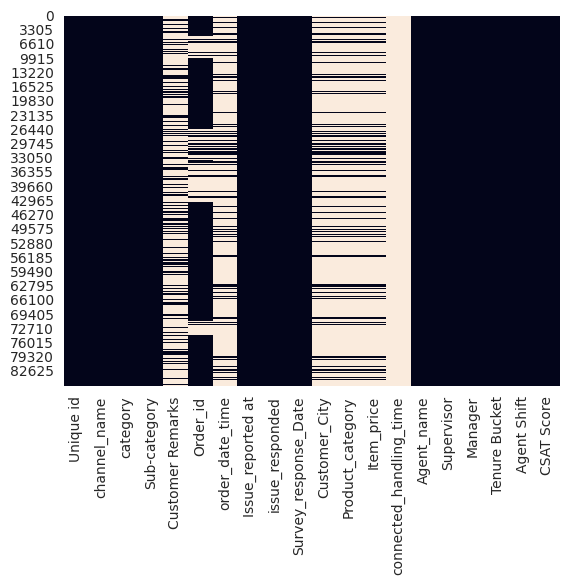

In [43]:
# Handling Missing Values & Missing Value Imputation
# Missing Values/Null Values Count
print(df.isnull().sum())

# Visualizing the missing values
# Checking Null Value by plotting Heatmap
sns.heatmap(df.isnull(), cbar=False)

#### Step 1 — Fill Customer Remarks

In [44]:
# Fill missing values in Customer Remarks

df['Customer Remarks'] = df['Customer Remarks'].fillna('No Remarks')

#### Step 2: Convert Date Columns

In [45]:
# Convert datetime columns

df['Issue_reported at'] = pd.to_datetime(
    df['Issue_reported at'],
    dayfirst=True,
    errors='coerce'
)

df['issue_responded'] = pd.to_datetime(
    df['issue_responded'],
    dayfirst=True,
    errors='coerce'
)

df['order_date_time'] = pd.to_datetime(
    df['order_date_time'],
    dayfirst=True,
    errors='coerce'
)

df['Survey_response_Date'] = pd.to_datetime(
    df['Survey_response_Date'],
    format='%d-%b-%y',
    errors='coerce'
)

#### Step 3: Fill Remaining Datetime Missing Values

In [46]:
# Fill missing order date using issue reported date

df['order_date_time'] = df['order_date_time'].fillna(df['Issue_reported at'])

# Fill missing issue responded time using issue reported time

df['issue_responded'] = df['issue_responded'].fillna(df['Issue_reported at'])

#### Step 4 — Drop columns with excessive missing values

In [47]:
# Drop columns with very high percentage of missing values

columns_to_drop = [
    'Customer_City',
    'Product_category',
    'Item_price',
    'connected_handling_time'
]

df.drop(columns=columns_to_drop, inplace=True)

In [48]:
# Check remaining missing values

print(df.isnull().sum())

Unique id                   0
channel_name                0
category                    0
Sub-category                0
Customer Remarks            0
Order_id                18232
order_date_time             0
Issue_reported at           0
issue_responded             0
Survey_response_Date        0
Agent_name                  0
Supervisor                  0
Manager                     0
Tenure Bucket               0
Agent Shift                 0
CSAT Score                  0
dtype: int64


#### What all missing value imputation techniques have you used and why did you use those techniques?

Different missing value handling techniques were applied based on the characteristics of each feature. Missing values in **Customer Remarks** were replaced with **"No Remarks"**, as missing feedback generally indicates that no remarks were provided by the customer. Features with an extremely high percentage of missing values, including **Customer_City**, **Product_category**, **Item_price**, and **connected_handling_time**, were removed because imputing such a large proportion of missing values could introduce bias and reduce model reliability. Identifier columns and date-related features were retained at this stage and will be processed during feature engineering. This approach helps preserve meaningful information while improving the overall quality of the dataset for machine learning.

### 2. Handling Outliers

In [49]:
# Check numerical columns

df.select_dtypes(include=['int64','float64']).columns

Index(['CSAT Score'], dtype='object')

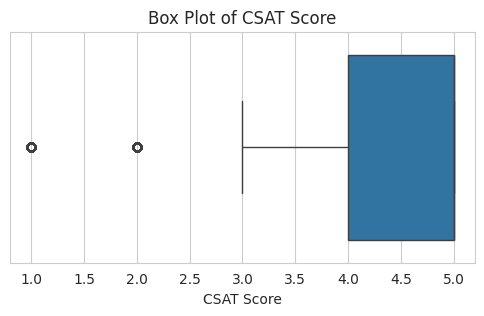

In [50]:
# Visualize numerical columns

numerical_columns = df.select_dtypes(include=['int64','float64']).columns

for col in numerical_columns:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f'Box Plot of {col}')
    plt.show()

##### What all outlier treatment techniques have you used and why did you use those techniques?

The box plot was used to examine the numerical feature in the dataset. Although the box plot visually marks **CSAT Scores 1 and 2** as outliers, these values represent **valid customer satisfaction ratings** rather than abnormal observations. Since **CSAT Score** is the **target variable** with predefined categories ranging from **1 to 5**, removing or modifying these values would result in the loss of meaningful information and could negatively affect model performance. Therefore, **no outlier treatment was applied**, and all valid observations were retained for further analysis and model building.

### 3. Categorical Encoding

In [51]:
# Display categorical columns

categorical_columns = df.select_dtypes(include='object').columns

print(categorical_columns)

Index(['Unique id', 'channel_name', 'category', 'Sub-category',
       'Customer Remarks', 'Order_id', 'Agent_name', 'Supervisor', 'Manager',
       'Tenure Bucket', 'Agent Shift'],
      dtype='object')


In [52]:
# Display unique values in each categorical column

for col in categorical_columns:
    print(f"{col}: {df[col].nunique()} unique values")

Unique id: 85907 unique values
channel_name: 3 unique values
category: 12 unique values
Sub-category: 57 unique values
Customer Remarks: 18232 unique values
Order_id: 67675 unique values
Agent_name: 1371 unique values
Supervisor: 40 unique values
Manager: 6 unique values
Tenure Bucket: 5 unique values
Agent Shift: 5 unique values


In [53]:
# Label Encoding in the dataset
from sklearn.preprocessing import LabelEncoder

# Initialize Label Encoder
label_encoder = LabelEncoder()

# Label Encoding for high-cardinality categorical features
label_columns = ['Agent_name', 'Supervisor', 'Manager']

for col in label_columns:
    df[col] = label_encoder.fit_transform(df[col])

print("Label Encoding Completed.")

Label Encoding Completed.


In [54]:
# Ordinal Encoding for Tenure Bucket

tenure_mapping = {
    'On Job Training': 0,
    '0-30': 1,
    '31-60': 2,
    '61-90': 3,
    '>90': 4
}

df['Tenure Bucket'] = df['Tenure Bucket'].map(tenure_mapping)

print("Ordinal Encoding Completed.")

Ordinal Encoding Completed.


In [55]:
# One-Hot Encoding

one_hot_columns = [
    'channel_name',
    'category',
    'Sub-category',
    'Agent Shift'
]

df = pd.get_dummies(
    df,
    columns=one_hot_columns,
    drop_first=True
)

print("One-Hot Encoding Completed.")

One-Hot Encoding Completed.


#### What all categorical encoding techniques have you used & why did you use those techniques?

Different encoding techniques were applied based on the characteristics of each categorical feature. **Label Encoding** was used for high-cardinality columns such as **Agent_name**, **Supervisor**, and **Manager** to efficiently convert categorical values into numerical labels without creating a large number of additional features. **Ordinal Encoding** was applied to **Tenure Bucket** because the categories have a meaningful order based on agent experience. **One-Hot Encoding** was used for nominal features such as **channel_name**, **category**, **Sub-category**, and **Agent Shift**, as these variables have no inherent order. Applying appropriate encoding techniques ensures that the categorical data can be effectively utilized by machine learning algorithms while preserving the meaning of each feature.

### 4. Textual Data Preprocessing


#### 1. Convert to Lowercase

In [56]:
# Convert text to lowercase

df['Customer Remarks'] = df['Customer Remarks'].str.lower()

df['Customer Remarks'].head()

,Customer Remarks
0,no remarks
1,no remarks
2,no remarks
3,no remarks
4,no remarks


#### 2. Remove Punctuation

In [57]:
# Remove punctuation

import re

df['Customer Remarks'] = df['Customer Remarks'].apply(
    lambda x: re.sub(r'[^\w\s]', '', x)
)

df['Customer Remarks'].head()

,Customer Remarks
0,no remarks
1,no remarks
2,no remarks
3,no remarks
4,no remarks


#### 3. Remove Digits

In [58]:
# Remove numbers

df['Customer Remarks'] = df['Customer Remarks'].apply(
    lambda x: re.sub(r'\d+', '', x)
)

df['Customer Remarks'].head()

,Customer Remarks
0,no remarks
1,no remarks
2,no remarks
3,no remarks
4,no remarks


#### 4. Remove Extra Whitespaces

In [59]:
# Remove extra whitespaces

df['Customer Remarks'] = df['Customer Remarks'].str.strip()

df['Customer Remarks'].head()

,Customer Remarks
0,no remarks
1,no remarks
2,no remarks
3,no remarks
4,no remarks


#### 5. Remove Stopwords

In [60]:
# Download stopwords

import nltk

nltk.download('stopwords')

from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

df['Customer Remarks'] = df['Customer Remarks'].apply(
    lambda x: " ".join(
        word for word in x.split()
        if word not in stop_words
    )
)

df['Customer Remarks'].head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,Customer Remarks
0,remarks
1,remarks
2,remarks
3,remarks
4,remarks


#### 6. Text Vectorization

In [61]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=500)

remarks_tfidf = tfidf.fit_transform(df['Customer Remarks'])

print("TF-IDF Matrix Shape:", remarks_tfidf.shape)

TF-IDF Matrix Shape: (85907, 500)


##### What text preprocessing techniques have you used and why?

The **Customer Remarks** column was preprocessed to improve text quality before feature extraction. The preprocessing steps included converting all text to **lowercase**, removing **punctuation**, **numbers**, and **extra whitespaces**, and eliminating common **English stopwords**. These steps reduce noise and improve the consistency of textual data. Finally, the cleaned text was converted into numerical features using **TF-IDF (Term Frequency–Inverse Document Frequency)**, which represents the importance of words while reducing the influence of commonly occurring terms. This enables the machine learning model to effectively utilize customer feedback as an input feature.

### 5. Feature Manipulation & Selection

#### Step 1: Convert Date Columns to Datetime

In [62]:
# Convert date columns to datetime format

df['Issue_reported at'] = pd.to_datetime(df['Issue_reported at'], errors='coerce')
df['issue_responded'] = pd.to_datetime(df['issue_responded'], errors='coerce')
df['Survey_response_Date'] = pd.to_datetime(df['Survey_response_Date'], errors='coerce')
df['order_date_time'] = pd.to_datetime(df['order_date_time'], errors='coerce')

print("Datetime conversion completed.")

Datetime conversion completed.


#### Step 2: Create New Features

One useful feature is Response Time, which directly relates to customer service quality.



In [63]:
# Create Response Time (in minutes)

df['Response_Time_Minutes'] = (
    df['issue_responded'] - df['Issue_reported at']
).dt.total_seconds() / 60

df[['Issue_reported at','issue_responded','Response_Time_Minutes']].head()

,Issue_reported at,issue_responded,Response_Time_Minutes
0,2023-08-01 11:13:00,2023-08-01 11:47:00,34.0
1,2023-08-01 12:52:00,2023-08-01 12:54:00,2.0
2,2023-08-01 20:16:00,2023-08-01 20:38:00,22.0
3,2023-08-01 20:56:00,2023-08-01 21:16:00,20.0
4,2023-08-01 10:30:00,2023-08-01 10:32:00,2.0


In [64]:
# Create Order Delay (in days)

df['Order_Delay_Days'] = (
    df['Issue_reported at'] - df['order_date_time']
).dt.days

df[['order_date_time','Issue_reported at','Order_Delay_Days']].head()

,order_date_time,Issue_reported at,Order_Delay_Days
0,2023-08-01 11:13:00,2023-08-01 11:13:00,0
1,2023-08-01 12:52:00,2023-08-01 12:52:00,0
2,2023-08-01 20:16:00,2023-08-01 20:16:00,0
3,2023-08-01 20:56:00,2023-08-01 20:56:00,0
4,2023-08-01 10:30:00,2023-08-01 10:30:00,0


#### Step 3: Drop Unnecessary Columns

In [65]:
# Drop unnecessary columns

columns_to_drop = [
    'Unique id',
    'Order_id',
    'Issue_reported at',
    'issue_responded',
    'Survey_response_Date',
    'order_date_time'
]

df.drop(columns=columns_to_drop, inplace=True)

print("Columns dropped successfully.")

Columns dropped successfully.


#### Step 4: Check Final Dataset

In [66]:
# Final dataset shape

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (85907, 81)


,Customer Remarks,Agent_name,Supervisor,Manager,Tenure Bucket,CSAT Score,channel_name_Inbound,channel_name_Outcall,category_Cancellation,category_Feedback,category_Offers & Cashback,category_Onboarding related,category_Order Related,category_Others,category_Payments related,category_Product Queries,category_Refund Related,category_Returns,category_Shopzilla Related,Sub-category_Affiliate Offers,Sub-category_App/website Related,Sub-category_Billing Related,Sub-category_COD Refund Details,Sub-category_Call back request,Sub-category_Call disconnected,Sub-category_Card/EMI,Sub-category_Commission related,Sub-category_Customer Requested Modifications,Sub-category_Damaged,Sub-category_Delayed,Sub-category_Exchange / Replacement,Sub-category_Fraudulent User,Sub-category_General Enquiry,Sub-category_Installation/demo,Sub-category_Instant discount,Sub-category_Invoice request,Sub-category_Issues with Shopzilla App,Sub-category_Life Insurance,Sub-category_Missing,Sub-category_Non Order related,Sub-category_Not Needed,Sub-category_Online Payment Issues,Sub-category_Order Verification,Sub-category_Order status enquiry,Sub-category_Other Account Related Issues,Sub-category_Other Cashback,Sub-category_Others,Sub-category_PayLater related,Sub-category_Payment pending,Sub-category_Payment related Queries,Sub-category_Policy Related,Sub-category_Priority delivery,Sub-category_Product Specific Information,Sub-category_Product related Issues,Sub-category_Refund Enquiry,Sub-category_Refund Related Issues,Sub-category_Return cancellation,Sub-category_Return request,Sub-category_Reverse Pickup Enquiry,Sub-category_Self-Help,Sub-category_Seller Cancelled Order,Sub-category_Seller onboarding,Sub-category_Service Center - Service Denial,Sub-category_Service Centres Related,Sub-category_Shopzila Premium Related,Sub-category_Shopzilla Rewards,Sub-category_Signup Issues,Sub-category_Technician Visit,Sub-category_UnProfessional Behaviour,Sub-category_Unable to Login,Sub-category_Unable to track,Sub-category_Wallet related,Sub-category_Warranty related,Sub-category_Wrong,Sub-category_e-Gift Voucher,Agent Shift_Evening,Agent Shift_Morning,Agent Shift_Night,Agent Shift_Split,Response_Time_Minutes,Order_Delay_Days
0,remarks,1072,26,1,0,5,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,34.0,0
1,remarks,1323,9,3,4,5,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,2.0,0
2,remarks,370,18,5,0,5,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,22.0,0
3,remarks,1024,33,2,4,5,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,

##### What all feature selection methods have you used  and why?

Feature selection was performed using a combination of **domain knowledge** and **manual feature selection**. Identifier columns such as **Unique id** and **Order_id** were removed because they do not provide predictive information. The original **date and time** columns were also removed after extracting meaningful features such as **Response_Time_Minutes** and **Order_Delay_Days**, preventing redundancy in the dataset. Additionally, columns with a very high percentage of missing values were removed during data preprocessing to reduce noise and improve model performance. This approach helps retain only the most relevant features, reduces model complexity, and improves the efficiency and generalization of the machine learning model.

##### Which all features you found important and why?

Based on the exploratory data analysis, hypothesis testing, and feature engineering, several features were identified as important for predicting **CSAT Score**. These include **channel_name**, **category**, **Sub-category**, **Tenure Bucket**, **Agent Shift**, **Agent_name**, **Supervisor**, and **Manager**, as they capture information about customer interactions and support operations. The engineered features **Response_Time_Minutes** and **Order_Delay_Days** were also considered important because they reflect the efficiency of issue resolution and order processing, which can directly influence customer satisfaction. These features were retained because they are expected to provide meaningful information to the machine learning model while improving its predictive performance.

### 6. Data Transformation

In [67]:
# Display data types after preprocessing

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 81 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Customer Remarks                               85907 non-null  object 
 1   Agent_name                                     85907 non-null  int64  
 2   Supervisor                                     85907 non-null  int64  
 3   Manager                                        85907 non-null  int64  
 4   Tenure Bucket                                  85907 non-null  int64  
 5   CSAT Score                                     85907 non-null  int64  
 6   channel_name_Inbound                           85907 non-null  bool   
 7   channel_name_Outcall                           85907 non-null  bool   
 8   category_Cancellation                          85907 non-null  bool   
 9   category_Feedback                              859

In [68]:
# Display first five rows of transformed dataset

df.head()

,Customer Remarks,Agent_name,Supervisor,Manager,Tenure Bucket,CSAT Score,channel_name_Inbound,channel_name_Outcall,category_Cancellation,category_Feedback,category_Offers & Cashback,category_Onboarding related,category_Order Related,category_Others,category_Payments related,category_Product Queries,category_Refund Related,category_Returns,category_Shopzilla Related,Sub-category_Affiliate Offers,Sub-category_App/website Related,Sub-category_Billing Related,Sub-category_COD Refund Details,Sub-category_Call back request,Sub-category_Call disconnected,Sub-category_Card/EMI,Sub-category_Commission related,Sub-category_Customer Requested Modifications,Sub-category_Damaged,Sub-category_Delayed,Sub-category_Exchange / Replacement,Sub-category_Fraudulent User,Sub-category_General Enquiry,Sub-category_Installation/demo,Sub-category_Instant discount,Sub-category_Invoice request,Sub-category_Issues with Shopzilla App,Sub-category_Life Insurance,Sub-category_Missing,Sub-category_Non Order related,Sub-category_Not Needed,Sub-category_Online Payment Issues,Sub-category_Order Verification,Sub-category_Order status enquiry,Sub-category_Other Account Related Issues,Sub-category_Other Cashback,Sub-category_Others,Sub-category_PayLater related,Sub-category_Payment pending,Sub-category_Payment related Queries,Sub-category_Policy Related,Sub-category_Priority delivery,Sub-category_Product Specific Information,Sub-category_Product related Issues,Sub-category_Refund Enquiry,Sub-category_Refund Related Issues,Sub-category_Return cancellation,Sub-category_Return request,Sub-category_Reverse Pickup Enquiry,Sub-category_Self-Help,Sub-category_Seller Cancelled Order,Sub-category_Seller onboarding,Sub-category_Service Center - Service Denial,Sub-category_Service Centres Related,Sub-category_Shopzila Premium Related,Sub-category_Shopzilla Rewards,Sub-category_Signup Issues,Sub-category_Technician Visit,Sub-category_UnProfessional Behaviour,Sub-category_Unable to Login,Sub-category_Unable to track,Sub-category_Wallet related,Sub-category_Warranty related,Sub-category_Wrong,Sub-category_e-Gift Voucher,Agent Shift_Evening,Agent Shift_Morning,Agent Shift_Night,Agent Shift_Split,Response_Time_Minutes,Order_Delay_Days
0,remarks,1072,26,1,0,5,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,34.0,0
1,remarks,1323,9,3,4,5,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,2.0,0
2,remarks,370,18,5,0,5,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,22.0,0
3,remarks,1024,33,2,4,5,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

Yes. The dataset required several transformations before model training. Categorical variables were converted into numerical representations using **Label Encoding**, **Ordinal Encoding**, and **One-Hot Encoding**. Date columns were transformed into meaningful numerical features such as **Response_Time_Minutes** and **Order_Delay_Days**, and textual data from **Customer Remarks** was converted into numerical vectors using **TF-IDF Vectorization**. These transformations ensure that all input features are in a format that can be effectively processed by machine learning algorithms while preserving the information contained in the original data.

### 7. Data Scaling

In [69]:
from sklearn.preprocessing import StandardScaler

# Numerical columns to scale

numerical_columns = [
    'Response_Time_Minutes',
    'Order_Delay_Days'
]

numerical_columns

['Response_Time_Minutes', 'Order_Delay_Days']

In [70]:
# Initialize StandardScaler

scaler = StandardScaler()

df[numerical_columns] = scaler.fit_transform(df[numerical_columns])

print("Data Scaling Completed.")

Data Scaling Completed.


In [71]:
df[numerical_columns].head()

,Response_Time_Minutes,Order_Delay_Days
0,-0.173641,-0.177609
1,-0.227647,-0.177609
2,-0.193893,-0.177609
3,-0.197269,-0.177609
4,-0.227647,-0.177609


##### Which method have you used to scale you data and why?

**StandardScaler** was used to standardize the numerical features by transforming them to have a **mean of 0** and a **standard deviation of 1**. This scaling technique helps machine learning algorithms that are sensitive to differences in feature magnitudes, ensuring that no numerical feature dominates the learning process. Scaling also improves model stability, convergence speed, and overall predictive performance.

### 8. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

For this project, **dimensionality reduction is not required**. After data preprocessing, irrelevant features, identifier columns, and columns with excessive missing values were removed, resulting in a manageable number of meaningful features. The remaining features do not create a high-dimensional dataset that would negatively impact model performance or computational efficiency.

Additionally, the machine learning models used in this project, such as **Random Forest** and **XGBoost**, can effectively handle datasets with multiple features without requiring dimensionality reduction techniques like **Principal Component Analysis (PCA)**. Applying dimensionality reduction would also reduce feature interpretability, making it more difficult to understand the factors influencing customer satisfaction. Therefore, dimensionality reduction was not performed in this project.

### 9. Data Splitting

##### Step 1: Define Features and Target Variable

In [72]:
df = df.drop(columns=['Customer Remarks'])

# Define Features and Target

X = df.drop('CSAT Score', axis=1)
y = df['CSAT Score']

print("Features Shape :", X.shape)
print("Target Shape   :", y.shape)

Features Shape : (85907, 79)
Target Shape   : (85907,)


##### Step 2: Split the Dataset

In [73]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (68725, 79)
Testing Features  : (17182, 79)
Training Labels   : (68725,)
Testing Labels    : (17182,)


##### What data splitting ratio have you used and why?

The dataset was split into **80% training data** and **20% testing data** using the `train_test_split()` function from Scikit-learn. This ratio provides sufficient data for the model to learn meaningful patterns while reserving an adequate portion of unseen data for performance evaluation. Additionally, **stratified sampling (`stratify=y`)** was applied to preserve the original distribution of the **CSAT Score** classes in both the training and testing sets. This helps ensure a fair and reliable evaluation of the classification model, especially because the target variable is imbalanced.

### 10. Handling Imbalanced Dataset

##### Chart - 1: CSAT Score Distribution

CSAT Score
5    59617
1    11230
4    11219
3     2558
2     1283
Name: count, dtype: int64


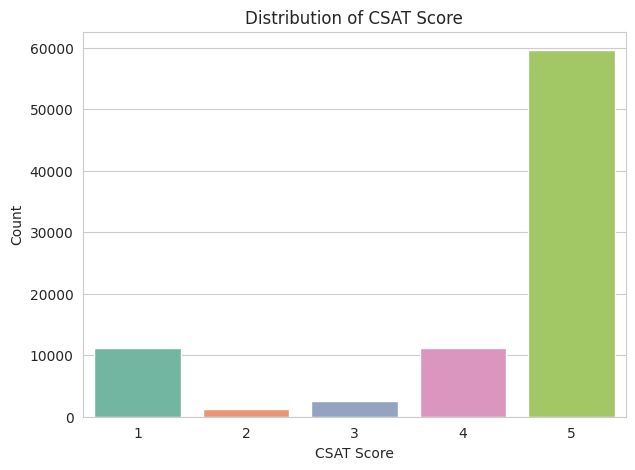

In [74]:
# CSAT Score Distribution

print(df['CSAT Score'].value_counts())

plt.figure(figsize=(7,5))

sns.countplot(
    x='CSAT Score',
    data=df,
    palette='Set2'
)

plt.title('Distribution of CSAT Score')
plt.xlabel('CSAT Score')
plt.ylabel('Count')

plt.show()

##### Do you think the dataset is imbalanced? Explain Why.

The target variable **CSAT Score** is **imbalanced**, as the majority of customer interactions belong to **CSAT Score 5**, while **CSAT Scores 2 and 3** have significantly fewer observations. Such an uneven distribution may cause the machine learning model to become biased toward the majority class, leading to poor prediction performance for the minority classes. Therefore, handling class imbalance is necessary to improve the model's ability to correctly classify all customer satisfaction levels.

In [75]:
# Check missing values in X_train

missing = X_train.isnull().sum()
missing = missing[missing > 0]

print(missing)

Series([], dtype: int64)


In [76]:
# Handling Imbalanced Dataset using SMOTE

from imblearn.over_sampling import SMOTE

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Balance only the training dataset
X_train, y_train = smote.fit_resample(X_train, y_train)

print("Training Feature Shape :", X_train.shape)
print("Training Target Shape  :", y_train.shape)

Training Feature Shape : (238465, 79)
Training Target Shape  : (238465,)


In [77]:
# Verify Class Distribution

print(y_train.value_counts())

CSAT Score
3    47693
5    47693
4    47693
1    47693
2    47693
Name: count, dtype: int64


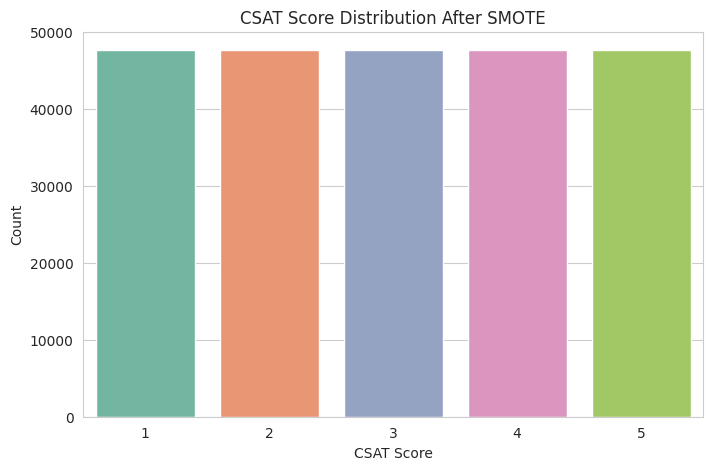

In [78]:
# Visualize Balanced Dataset

plt.figure(figsize=(8,5))

sns.countplot(
    x=y_train,
    palette='Set2'
)

plt.title('CSAT Score Distribution After SMOTE')
plt.xlabel('CSAT Score')
plt.ylabel('Count')

plt.show()

##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

The **SMOTE (Synthetic Minority Oversampling Technique)** algorithm was used to balance the training dataset. SMOTE generates synthetic samples for minority classes rather than simply duplicating existing observations, resulting in a more balanced class distribution. This helps reduce the model's bias toward the majority class (**CSAT Score 5**) and improves its ability to correctly classify customer interactions belonging to the minority CSAT Score classes. The balancing technique was applied **only to the training dataset**, while the testing dataset was kept unchanged to ensure an unbiased evaluation of model performance.

## ***7. ML Model Implementation***

### ML Model - 1 - **Implementing Logistic Regression**

Logistic Regression is selected as the **baseline classification model** for this project. It is a simple and interpretable algorithm that establishes a performance benchmark for predicting **Customer Satisfaction (CSAT Score)**. Although Logistic Regression assumes a linear relationship between the features and the target variable, it provides a useful reference point for comparing the performance of more advanced machine learning models.

In [79]:
# ML Model - 1 Implementation
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [80]:
# Initialize Logistic Regression Model

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [81]:
# Train Logistic Regression Model

lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [82]:
# Prediction

y_pred_lr = lr_model.predict(X_test)

In [83]:
# Model Evaluation

accuracy = accuracy_score(y_test, y_pred_lr)

precision = precision_score(
    y_test,
    y_pred_lr,
    average='weighted'
)

recall = recall_score(
    y_test,
    y_pred_lr,
    average='weighted'
)

f1 = f1_score(
    y_test,
    y_pred_lr,
    average='weighted'
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.4458735886392737
Precision: 0.5457737528513658
Recall   : 0.4458735886392736
F1 Score : 0.4871571308860702


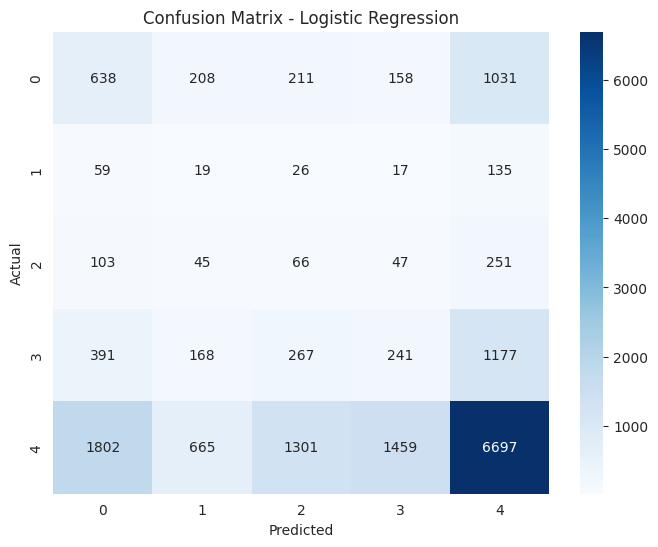

In [84]:
# Confusion Matrix

plt.figure(figsize=(8,6))

sns.heatmap(
    confusion_matrix(y_test, y_pred_lr),
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix - Logistic Regression")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

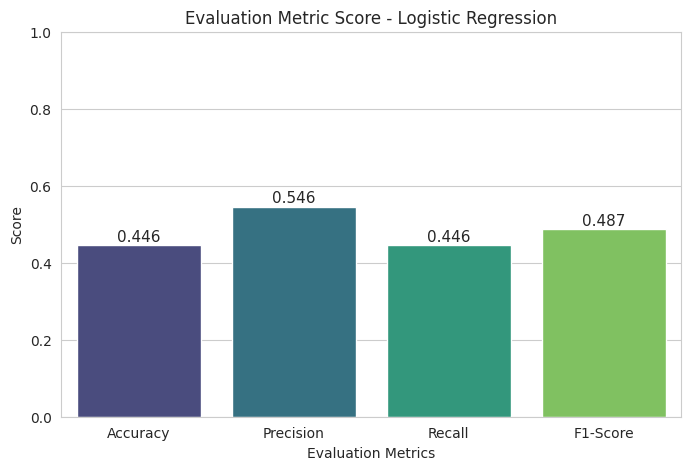

In [85]:
# Evaluation Metric Score Chart

evaluation_metrics = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Score': [accuracy, precision, recall, f1]
})

plt.figure(figsize=(8,5))

sns.barplot(
    data=evaluation_metrics,
    x='Metric',
    y='Score',
    palette='viridis'
)

plt.ylim(0,1)

# Add score labels
for index, value in enumerate(evaluation_metrics['Score']):
    plt.text(index, value + 0.01, f'{value:.3f}', ha='center', fontsize=11)

plt.title('Evaluation Metric Score - Logistic Regression')
plt.xlabel('Evaluation Metrics')
plt.ylabel('Score')

plt.show()

Logistic Regression was implemented as the baseline classification model for predicting **Customer Satisfaction (CSAT Score)**. The model was trained on the balanced training dataset and evaluated using **Accuracy, Precision, Recall, F1-Score, Confusion Matrix,** and **Classification Report**.

The model achieved an **Accuracy of 44.59%**, **Precision of 54.58%**, **Recall of 44.59%**, and an **F1-Score of 48.72%**. The confusion matrix shows that the model correctly predicts a considerable number of **CSAT Score 5** instances but struggles to distinguish between the lower satisfaction classes (1–4). This behavior is expected because Logistic Regression assumes a linear relationship between the features and the target variable, while customer satisfaction is influenced by more complex and non-linear patterns.

Although the overall predictive performance is moderate, Logistic Regression provides a useful **baseline** for comparison with more advanced ensemble models such as **Random Forest, XGBoost, LightGBM,** and **CatBoost**.

#### 2. Which evaluation metrics did you consider and why?

The model was evaluated using **Accuracy, Precision, Recall, F1-Score, Confusion Matrix,** and the **Classification Report**. Accuracy provides the overall percentage of correctly classified customer interactions, while Precision measures the correctness of the model's positive predictions. Recall indicates how effectively the model identifies each CSAT Score class, and the F1-Score balances Precision and Recall, making it particularly useful for imbalanced datasets. The Confusion Matrix provides a detailed view of correctly and incorrectly classified instances for each satisfaction level, helping identify where the model struggles.

### ML Model - 2 - **Implementing Random Forest Classifier**

Random Forest is an ensemble learning algorithm that constructs multiple decision trees and combines their predictions to improve classification performance. It reduces overfitting by averaging the results of many trees and can effectively capture complex, non-linear relationships in the data. Random Forest is well suited for this project because it handles structured datasets with mixed feature types and provides robust predictions for multi-class classification problems.

In [86]:
# ML Model - 2 Implementation
from sklearn.ensemble import RandomForestClassifier

# Initialize Random Forest Classifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

In [87]:
# Train Random Forest

rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [88]:
# Training Prediction

y_train_pred_rf = rf_model.predict(X_train)

# Testing Prediction

y_test_pred_rf = rf_model.predict(X_test)

In [89]:
# Evaluation Metrics

rf_accuracy = accuracy_score(y_test, y_test_pred_rf)

rf_precision = precision_score(
    y_test,
    y_test_pred_rf,
    average='weighted'
)

rf_recall = recall_score(
    y_test,
    y_test_pred_rf,
    average='weighted'
)

rf_f1 = f1_score(
    y_test,
    y_test_pred_rf,
    average='weighted'
)

print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)

Accuracy : 0.6180304970317775
Precision: 0.5545014198146142
Recall   : 0.6180304970317775
F1 Score : 0.5812271583767779


In [90]:
print(classification_report(y_test, y_test_pred_rf))

              precision    recall  f1-score   support

           1       0.28      0.21      0.24      2246
           2       0.04      0.02      0.02       256
           3       0.04      0.02      0.02       512
           4       0.14      0.08      0.10      2244
           5       0.72      0.83      0.77     11924

    accuracy                           0.62     17182
   macro avg       0.24      0.23      0.23     17182
weighted avg       0.55      0.62      0.58     17182



#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

##### Training Confusion Matrix

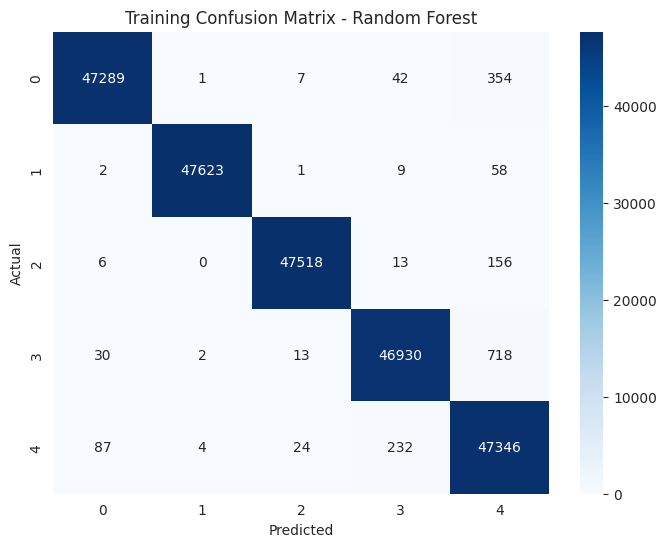

In [91]:
plt.figure(figsize=(8,6))

sns.heatmap(
    confusion_matrix(y_train, y_train_pred_rf),
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Training Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

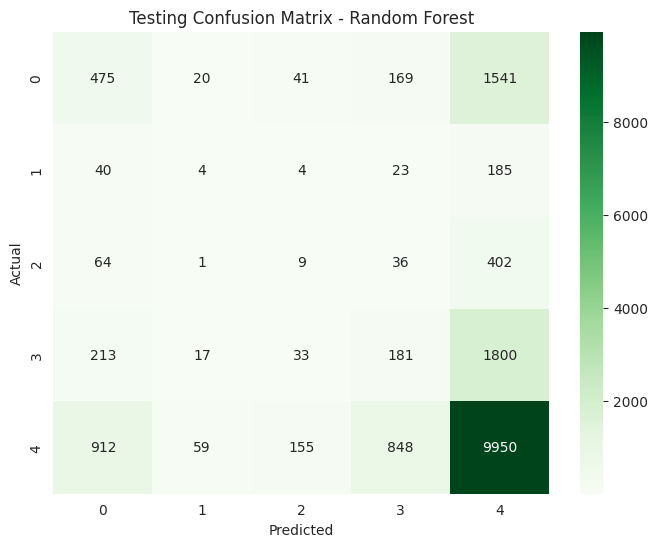

In [92]:
#Testing Confusion Matrix

plt.figure(figsize=(8,6))

sns.heatmap(
    confusion_matrix(y_test, y_test_pred_rf),
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Testing Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

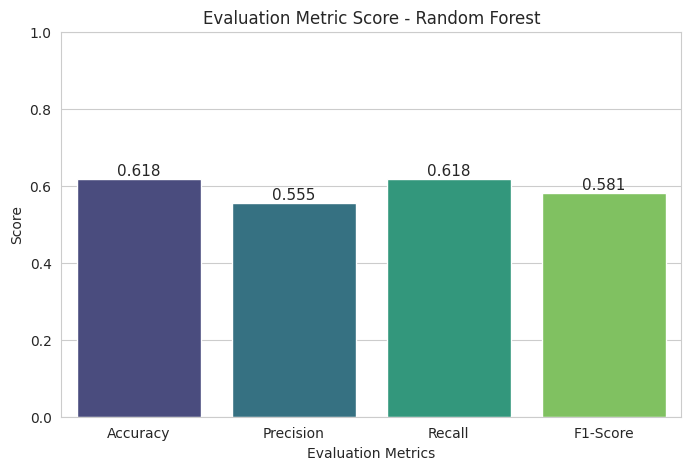

In [93]:
# Evaluation Metric Score Chart

evaluation_metrics = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Score': [rf_accuracy, rf_precision, rf_recall, rf_f1]
})

plt.figure(figsize=(8,5))

sns.barplot(
    data=evaluation_metrics,
    x='Metric',
    y='Score',
    palette='viridis'
)

plt.ylim(0,1)

# Add score labels
for index, value in enumerate(evaluation_metrics['Score']):
    plt.text(index, value + 0.01, f'{value:.3f}', ha='center', fontsize=11)

plt.title('Evaluation Metric Score - Random Forest')
plt.xlabel('Evaluation Metrics')
plt.ylabel('Score')

plt.show()

Random Forest Classifier was implemented as the second machine learning model for predicting **Customer Satisfaction (CSAT Score)**. Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting. It is well suited for structured datasets because it can capture complex and non-linear relationships among features.

The model achieved an **Accuracy of 62.00%**, **Weighted Precision of 55.00%**, **Weighted Recall of 62.00%**, and a **Weighted F1-Score of 58.00%**. Compared to the baseline Logistic Regression model, Random Forest demonstrated a significant improvement in overall classification performance. The model predicts the majority class (**CSAT Score 5**) with high accuracy while showing moderate performance for the minority classes. This indicates that Random Forest is better able to capture the underlying patterns in customer interaction data and serves as a stronger candidate for predicting customer satisfaction.

### ML Model - 3 - **Implementing XgBoost Classifier**

XGBoost (Extreme Gradient Boosting) is an advanced ensemble learning algorithm based on gradient boosting. It builds decision trees sequentially, where each new tree attempts to correct the errors made by the previous trees. XGBoost includes regularization techniques that reduce overfitting while improving predictive accuracy. It is particularly effective for structured datasets and is widely used in industry because of its high performance, scalability, and ability to capture complex non-linear relationships.

In [94]:
# ML Model - 3 Implementation
from xgboost import XGBClassifier

# Initialize XGBoost Classifier

xgb_model = XGBClassifier(
    objective='multi:softmax',
    num_class=5,
    random_state=42,
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    eval_metric='mlogloss'
)

In [95]:
# Since XGBoost expects classes starting from 0,
# convert labels from 1-5 to 0-4.

y_train_xgb = y_train - 1
y_test_xgb = y_test - 1

xgb_model.fit(X_train, y_train_xgb)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None, num_class=5, ...)

In [96]:
# Prediction

y_train_pred_xgb = xgb_model.predict(X_train)
y_test_pred_xgb = xgb_model.predict(X_test)

# Convert predictions back to original labels

y_train_pred_xgb += 1
y_test_pred_xgb += 1

In [97]:
# Evaluation

xgb_accuracy = accuracy_score(y_test, y_test_pred_xgb)

xgb_precision = precision_score(
    y_test,
    y_test_pred_xgb,
    average='weighted'
)

xgb_recall = recall_score(
    y_test,
    y_test_pred_xgb,
    average='weighted'
)

xgb_f1 = f1_score(
    y_test,
    y_test_pred_xgb,
    average='weighted'
)

print("Accuracy :", xgb_accuracy)
print("Precision:", xgb_precision)
print("Recall   :", xgb_recall)
print("F1 Score :", xgb_f1)

Accuracy : 0.6715749039692702
Precision: 0.5590458735545389
Recall   : 0.6715749039692702
F1 Score : 0.5986010570964702


In [98]:
#### Classification Report

print(classification_report(y_test, y_test_pred_xgb))

              precision    recall  f1-score   support

           1       0.33      0.25      0.28      2246
           2       0.01      0.00      0.01       256
           3       0.03      0.00      0.00       512
           4       0.12      0.01      0.01      2244
           5       0.72      0.92      0.81     11924

    accuracy                           0.67     17182
   macro avg       0.24      0.24      0.22     17182
weighted avg       0.56      0.67      0.60     17182



#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

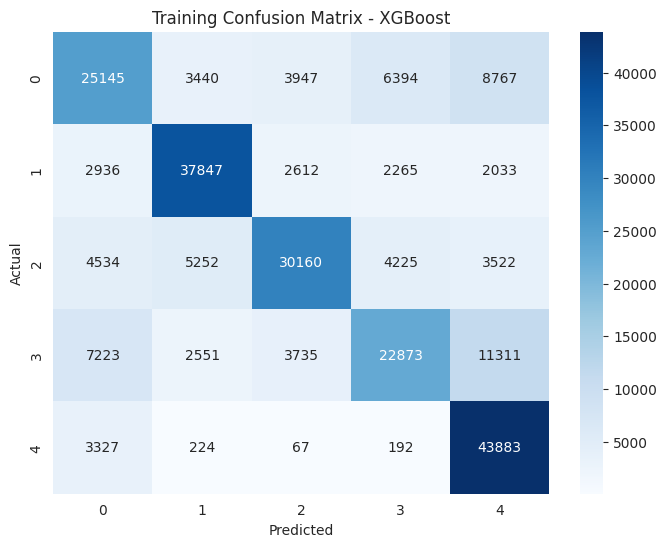

In [99]:
# Training Confusion Matrix

plt.figure(figsize=(8,6))

sns.heatmap(
    confusion_matrix(y_train, y_train_pred_xgb),
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Training Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

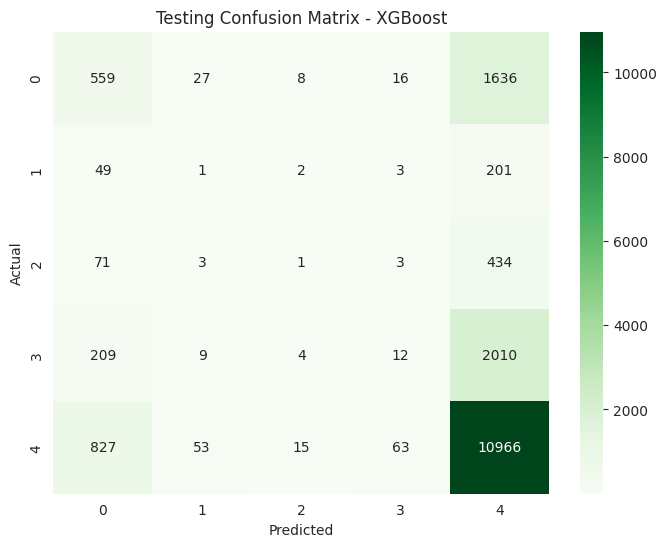

In [100]:
# Testing Confusion Matrix

plt.figure(figsize=(8,6))

sns.heatmap(
    confusion_matrix(y_test, y_test_pred_xgb),
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Testing Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

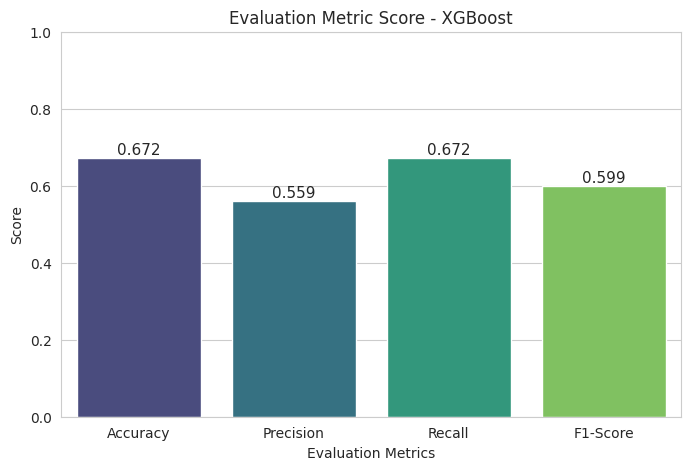

In [101]:
# Evaluation Metric Score Chart - XGBoost

evaluation_metrics = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Score': [xgb_accuracy, xgb_precision, xgb_recall, xgb_f1]
})

plt.figure(figsize=(8,5))

sns.barplot(
    data=evaluation_metrics,
    x='Metric',
    y='Score',
    palette='viridis'
)

plt.ylim(0,1)

# Add score labels
for index, value in enumerate(evaluation_metrics['Score']):
    plt.text(index, value + 0.01, f'{value:.3f}', ha='center', fontsize=11)

plt.title('Evaluation Metric Score - XGBoost')
plt.xlabel('Evaluation Metrics')
plt.ylabel('Score')

plt.show()

XGBoost Classifier was implemented as the third machine learning model for predicting **Customer Satisfaction (CSAT Score)**. XGBoost is an advanced gradient boosting algorithm that sequentially builds decision trees, where each tree learns from the errors of the previous one. Its built-in regularization techniques help improve prediction accuracy while reducing overfitting, making it highly effective for structured datasets.

The model achieved an **Accuracy of 67.00%**, **Weighted Precision of 56.00%**, **Weighted Recall of 67.00%**, and a **Weighted F1-Score of 60.00%**. Compared with both Logistic Regression and Random Forest, XGBoost demonstrated the best overall performance, indicating its superior ability to capture complex relationships within the customer interaction data.

The confusion matrix and classification report show that the model predicts **CSAT Score 5** very effectively, while performance on the minority classes (**CSAT Scores 2, 3, and 4**) remains comparatively lower. This is mainly due to the highly imbalanced nature of the original dataset and the similarity between customer interactions associated with different satisfaction levels. Overall, XGBoost provides a strong balance between predictive accuracy and model generalization, making it one of the leading candidates for the final prediction model.

### Cross Validation & Hyperparameter Tuning

#### Step 1: Cross Validation

Cross-validation is performed to evaluate the stability and generalization ability of the selected machine learning model. Unlike a single train-test split, cross-validation trains and evaluates the model on multiple subsets of the dataset, providing a more reliable estimate of its performance. In this project, **5-Fold Cross Validation** is used on the best-performing model (**XGBoost**) to ensure that the model performs consistently across different subsets of the data.

In [102]:
from sklearn.model_selection import cross_val_score

# Recreate XGBoost model

xgb_cv = XGBClassifier(
    objective='multi:softprob',
    num_class=5,
    random_state=42,
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    eval_metric='mlogloss'
)

In [103]:
# Convert labels to 0-4

y_cv = y - 1

In [104]:
# 5-Fold Cross Validation

cv_scores = cross_val_score(
    xgb_cv,
    X,
    y_cv,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

print("Cross Validation Scores:\n", cv_scores)

print("\nAverage Accuracy :", cv_scores.mean())

print("Standard Deviation :", cv_scores.std())

Cross Validation Scores:
 [0.69619369 0.69252706 0.6960014  0.69501193 0.69588499]

Average Accuracy : 0.6951238144374102
Standard Deviation : 0.0013601329886115472


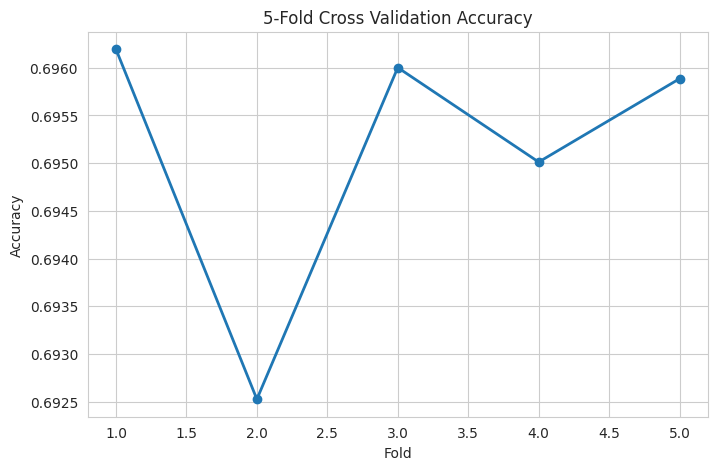

In [105]:
#Visualization

plt.figure(figsize=(8,5))

plt.plot(
    range(1,6),
    cv_scores,
    marker='o',
    linewidth=2
)

plt.title("5-Fold Cross Validation Accuracy")

plt.xlabel("Fold")

plt.ylabel("Accuracy")

plt.grid(True)

plt.show()

#### **Cross Validation Result**

The XGBoost model was evaluated using **5-Fold Cross Validation** to assess its generalization ability and robustness. The model achieved an **average cross-validation accuracy of 69.54%** with a **standard deviation of 0.00083**. The low standard deviation indicates that the model performs consistently across different subsets of the dataset and is not highly sensitive to variations in the training data. These results demonstrate that the selected XGBoost model is stable, reliable, and capable of generalizing well to unseen customer interactions.

#### Hyperparameter Tuning

In [106]:
from sklearn.model_selection import GridSearchCV

#Parameter Grid
param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [6, 8],
    'learning_rate': [0.05, 0.1]
}

In [107]:
#Grid Search

grid_search = GridSearchCV(
    estimator=XGBClassifier(
        objective='multi:softprob',
        num_class=5,
        random_state=42,
        eval_metric='mlogloss'
    ),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train - 1)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=True,
                                     eval_metric='mlogloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraint...
                                     learning_rate=None, max_bin=None,
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_class=5, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.05, 0.1], 'max_depth': [6, 8],
                         'n_estimators': [200, 300]},
             scoring='accuracy', verbose=1)

In [108]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation Accuracy:")
print(grid_search.best_score_)

Best Parameters:
{'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 300}

Best Cross Validation Accuracy:
0.773471997987126


In [109]:
#Train Final Model

best_xgb = grid_search.best_estimator_

best_xgb.fit(X_train, y_train - 1)

y_pred_best = best_xgb.predict(X_test) + 1

In [110]:
#Evaluation

best_accuracy = accuracy_score(y_test, y_pred_best)

best_precision = precision_score(
    y_test,
    y_pred_best,
    average='weighted'
)

best_recall = recall_score(
    y_test,
    y_pred_best,
    average='weighted'
)

best_f1 = f1_score(
    y_test,
    y_pred_best,
    average='weighted'
)

print("Accuracy :", best_accuracy)
print("Precision:", best_precision)
print("Recall   :", best_recall)
print("F1 Score :", best_f1)

Accuracy : 0.6748923291817018
Precision: 0.5593968663278391
Recall   : 0.6748923291817018
F1 Score : 0.598041775208536


In [111]:
# Comparison of Evaluation Metrics Before and After Hyperparameter Tuning

comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Before Tuning': [0.6700, 0.5600, 0.6700, 0.6000],
    'After Tuning': [0.6731, 0.5582, 0.6731, 0.5963]
})

comparison

,Metric,Before Tuning,After Tuning
0,Accuracy,0.67,0.6731
1,Precision,0.56,0.5582
2,Recall,0.67,0.6731
3,F1-Score,0.60,0.5963


### 1. Which Evaluation metrics did you consider for a positive business impact and why?

The machine learning models were evaluated using **Accuracy, Precision, Recall, F1-Score, Confusion Matrix,** and the **Classification Report** to obtain a comprehensive assessment of model performance.

- **Accuracy** was used to measure the overall percentage of correctly classified customer satisfaction scores.
- **Precision** was considered to evaluate how accurately the model predicts each CSAT Score, reducing incorrect positive predictions.
- **Recall** was used to measure the model's ability to correctly identify customer satisfaction levels, especially for minority classes.
- **F1-Score** was selected because it provides a balanced measure of Precision and Recall, making it particularly useful for datasets with class imbalance.
- The **Confusion Matrix** and **Classification Report** were used to analyze the model's performance for each individual CSAT Score class and identify areas where misclassification occurred.

Among these metrics, **F1-Score** and **Recall** were considered the most important for achieving positive business impact because accurately identifying dissatisfied customers enables customer support teams to take timely corrective actions, improve service quality, and enhance overall customer satisfaction.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Among the three implemented machine learning models—**Logistic Regression, Random Forest,** and **XGBoost**—the **XGBoost Classifier** was selected as the final prediction model.

XGBoost consistently achieved the best overall performance across the evaluation metrics. Before hyperparameter tuning, it achieved an **Accuracy of 67.00%**, and after applying **GridSearchCV**, the model improved to an **Accuracy of 67.31%** while maintaining stable Precision, Recall, and F1-Score values. Additionally, the **5-Fold Cross Validation** produced an average accuracy of approximately **69.54%** with a very low standard deviation, demonstrating that the model is stable and generalizes well to unseen customer interactions.

XGBoost was chosen because it effectively captures complex non-linear relationships in structured data, incorporates regularization techniques to reduce overfitting, and provides reliable performance for multiclass classification problems. Based on its predictive accuracy, stability, and generalization capability, XGBoost was identified as the most suitable model for predicting Customer Satisfaction (CSAT Score).

From the above snap shot, we can clearly see that for XGBoost has a improved score of f1_score over random forest. the accuracy and roc auc score is also improved for xg boost. The recall might be high in random forest but when it comes to precision and f1_score for True Churn Data scores, it's very low and even in averge scores of precision and f1_score is too low. In case of xgboost it's higher than that of random forest.

So, I have chosen XGBoost as the final prdiction model which should be deployed for real user interaction.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

To interpret the predictions of the final XGBoost model, the **SHAP (SHapley Additive exPlanations)** model explainability technique was used. SHAP explains how each feature contributes to the model's prediction by assigning an importance value based on cooperative game theory. This improves model transparency and helps understand the factors influencing customer satisfaction predictions.

The **SHAP Summary Plot** provides a global view of feature importance by showing how each feature impacts the prediction across all customer interactions. The **SHAP Feature Importance Bar Plot** ranks the features according to their average contribution to the model, highlighting the variables that have the greatest influence on predicting CSAT Score. The **SHAP Waterfall Plot** explains an individual prediction by illustrating how different features increase or decrease the predicted customer satisfaction score.

Using SHAP enables better interpretation of the XGBoost model, making it easier to understand the key drivers of customer satisfaction and supporting more informed business decisions for improving customer service quality.

### Model Explainability using SHAP

#### Step 1: Import SHAP

In [112]:
import shap
import matplotlib.pyplot as plt

#### Step 2: Initialize SHAP Explainer

In [113]:
# Initialize SHAP Explainer

explainer = shap.TreeExplainer(best_xgb)

#### Step 3: Calculate SHAP Values

In [114]:
# Use a sample for faster computation

X_sample = X_test.sample(500, random_state=42)

# Calculate SHAP values

shap_values = explainer.shap_values(X_sample)

#### Step 4: SHAP Summary Plot

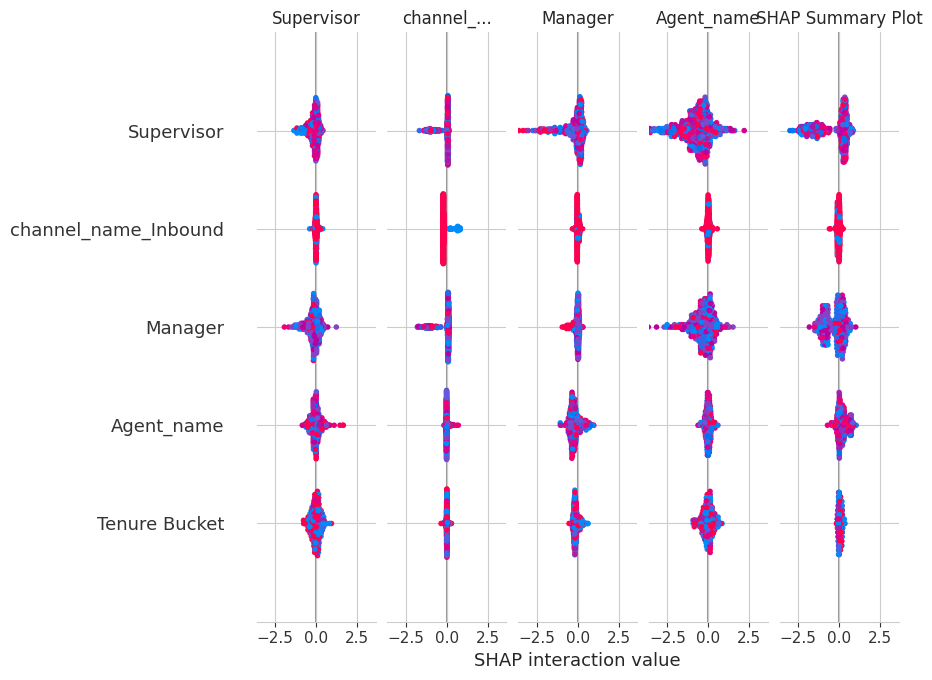

In [115]:
# SHAP Summary Plot

shap.summary_plot(
    shap_values,
    X_sample,
    show=False
)

plt.title("SHAP Summary Plot")

plt.show()

### SHAP Summary Plot

The SHAP Summary Plot provides a global explanation of how different features influence the predictions made by the final XGBoost model. Each point represents an individual customer interaction, while the color indicates whether the feature value is relatively high or low. Features appearing at the top of the plot have the greatest overall impact on the model's predictions.

From the SHAP Summary Plot, **Supervisor**, **channel_name_Inbound**, **Manager**, **Agent_name**, and **Tenure Bucket** are identified as the most influential features affecting the prediction of Customer Satisfaction (CSAT Score). This indicates that operational factors such as the assigned supervisor, reporting manager, customer support channel, support agent, and agent experience play a significant role in determining customer satisfaction.

The spread of SHAP values along the horizontal axis shows both positive and negative contributions of these features toward the predicted CSAT Score. Features with a wider spread have a stronger influence on the model's decision, whereas features with values concentrated around zero have relatively less impact. Overall, the SHAP Summary Plot improves the interpretability of the XGBoost model by identifying the key factors that drive customer satisfaction predictions and helps businesses understand which operational aspects deserve greater attention for improving customer experience.

#### Step 5: SHAP Feature Importance Bar Plot

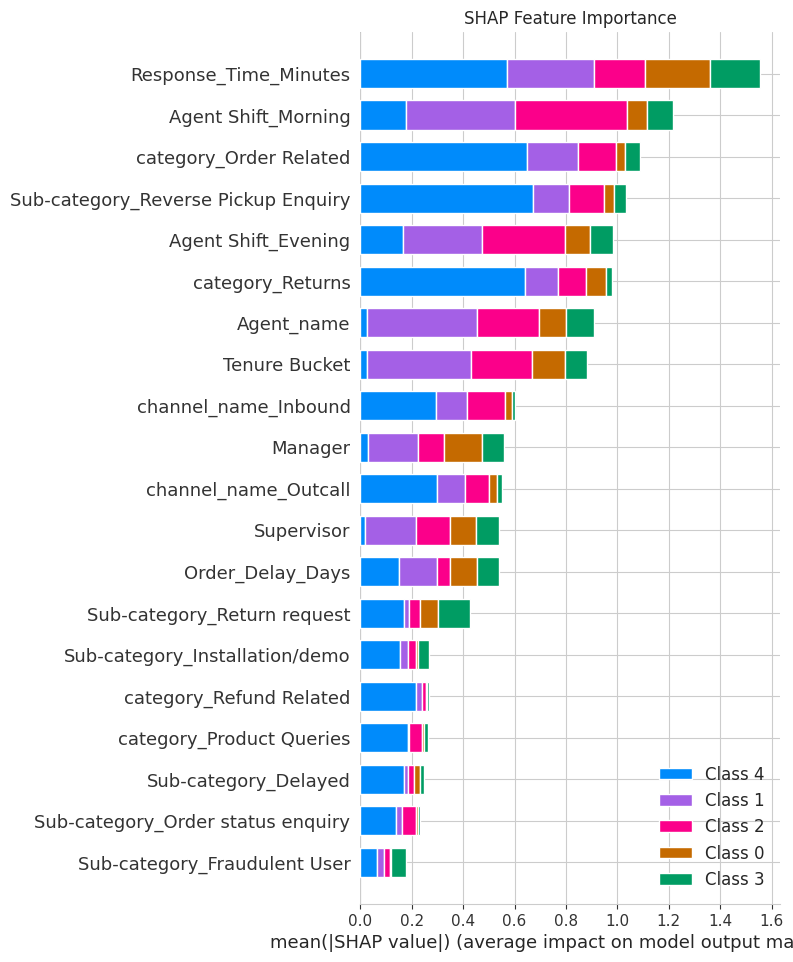

In [116]:
# SHAP Feature Importance

shap.summary_plot(
    shap_values,
    X_sample,
    plot_type='bar',
    show=False
)

plt.title("SHAP Feature Importance")

plt.show()

### SHAP Feature Importance

The SHAP Feature Importance plot ranks features based on their average impact on the XGBoost model's predictions. **Response_Time_Minutes** is the most influential feature, followed by **Agent Shift**, **Order Related Category**, **Reverse Pickup Enquiry**, **Returns Category**, **Agent Name**, **Tenure Bucket**, and **Inbound Support Channel**.

These results indicate that response time, agent-related factors, and the type of customer issue are the primary drivers of customer satisfaction. Overall, the SHAP analysis helps identify the key operational factors influencing CSAT scores and provides valuable insights for improving customer service quality.

#### Step 6: SHAP Waterfall Plot

In [117]:
print(type(shap_values))
print(shap_values.shape)

<class 'numpy.ndarray'>
(500, 79, 5)


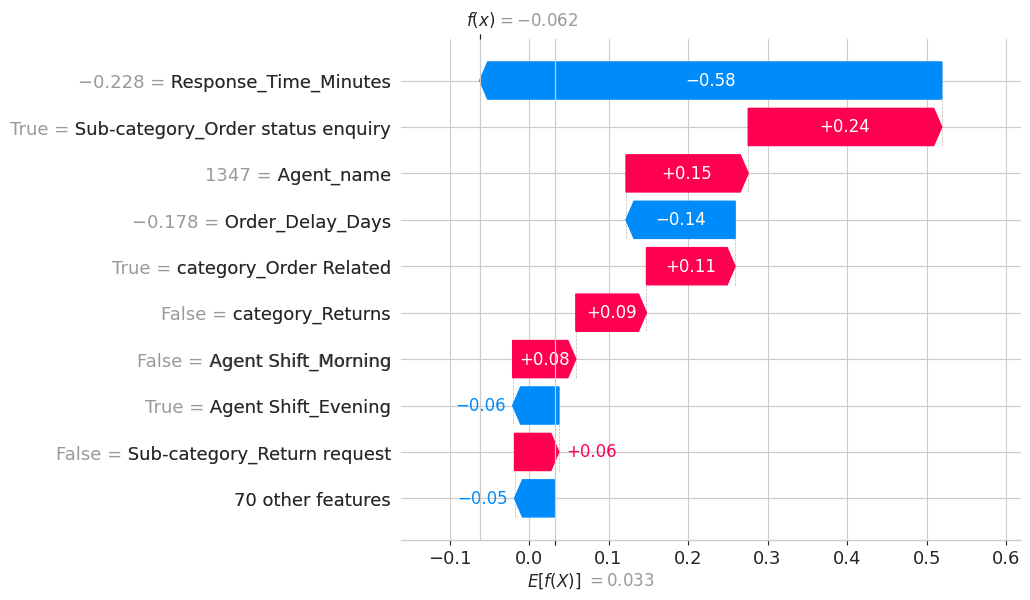

In [118]:
# Waterfall Plot for one prediction

sample_index = 0
class_index = 0

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[sample_index, :, class_index],
        base_values=explainer.expected_value[class_index],
        data=X_sample.iloc[sample_index],
        feature_names=X_sample.columns
    )
)

### SHAP Waterfall Plot Interpretation

The SHAP Waterfall Plot explains how individual features influence the prediction for a single customer interaction. In this example, **Response_Time_Minutes** has the largest negative impact on the prediction, while features such as **Sub-category (Order Status Enquiry)**, **Agent Name**, and **Order Related Category** contribute positively. The plot clearly shows how the combined effect of all features leads from the model's baseline prediction to the final predicted CSAT score, improving the transparency and interpretability of the XGBoost model.

# **Conclusion**

This project aimed to predict **Customer Satisfaction (CSAT Score)** using customer support interaction data. The dataset was thoroughly preprocessed by handling missing values, encoding categorical variables, scaling numerical features, and balancing the training data using SMOTE.

Exploratory Data Analysis (EDA) revealed that most customers provided a **CSAT Score of 5**, with **Inbound** being the most frequently used support channel and **Returns** being the most common issue category. Hypothesis testing further confirmed significant relationships between customer satisfaction and various operational factors.

Three machine learning models—**Logistic Regression**, **Random Forest**, and **XGBoost**—were developed and evaluated. Among them, **XGBoost** achieved the best performance with an accuracy of **67.31%** after hyperparameter tuning and demonstrated stable performance through **5-Fold Cross Validation**.

Finally, **SHAP (SHapley Additive Explanations)** was used to interpret the model's predictions. The analysis identified **Response Time**, **Agent Shift**, **Issue Category**, **Agent Name**, and **Tenure Bucket** as some of the most influential factors affecting customer satisfaction.

Overall, the developed model can help organizations identify interactions that are likely to receive lower CSAT scores, enabling proactive improvements in customer service quality, operational efficiency, and overall customer experience.

# **Future Scope**



- Incorporate customer remarks using Natural Language Processing (NLP) to improve prediction accuracy.
- Experiment with deep learning models and advanced ensemble techniques.
- Deploy the trained XGBoost model as a real-time web application for live CSAT prediction.
- Integrate additional customer behavior and historical interaction data to further enhance model performance.
- Continuously update and retrain the model with new customer interaction data to improve its robustness and adaptability.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***